# Vehicle Acoustic Classification V12 — IDMT + Melaudis + UrbanSound8K

## What's New in V12 vs V11
- **3 datasets**: IDMT-Traffic + Melaudis + UrbanSound8K (US8K)
- **9 classes** instead of 7: addition of `Horn`, `Dog`, `Construction`, `Siren`
- **Bicycle and electric car → BG** (too quiet to be reliably classified)
- **Target of 1,200 samples per class** maintained

## Expected File Structure

```
projet/
├── IDMT_Traffic/
│   ├── audio/
│   └── annotation/
│       ├── eusipco_2021_train.txt
│       └── eusipco_2021_test.txt
├── data/
│   ├── MELAUDIS_Vehicles/
│   ├── MELAUDIS_BG/
│   └── us8k_filtered/         ← UrbanSound8K filtré (Horn/Dog/Construction/Siren)
│       ├── train/  Horn/ Dog/ Construction/ Siren/
│       ├── val/    Horn/ Dog/ Construction/ Siren/
│       └── test/   Horn/ Dog/ Construction/ Siren/
├── audio/                     ← Enregistrements personnels
└── results/
```

## Final Classes — 9 classes
| Source | Original Class | Final Class |
|--------|----------------|-------------|
| IDMT + Melaudis | BG + Bicycle | BG |
| IDMT + Melaudis | MC | MC |
| IDMT + Melaudis | Car (+ electric car) | Car |
| IDMT + Melaudis | Bus | Bus |
| IDMT + Melaudis | Truck | Truck |
| IDMT + Melaudis | Tram | Tram |
| US8K | car_horn (1) | Horn |
| US8K | dog_bark (3) | Dog |
| US8K | drilling (4) + jackhammer (7) | Construction |
| US8K | siren (8) | Siren |

## 0. Installation & Dependecies

In [5]:
# Uncomment if needed:
# import subprocess, sys
# subprocess.run([sys.executable, '-m', 'pip', 'install',
#     'tensorflow', 'librosa', 'soundfile',
#     'scikit-learn', 'matplotlib', 'tqdm', 'pandas', '--quiet'])
print('Dependencies OK')

Dependencies OK


## 1. Imports & Configuration

In [6]:
import os, sys, random, time, warnings, re
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import pandas as pd
from collections import Counter, defaultdict
from tqdm.notebook import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow : {tf.__version__}')
print(f'Python     : {sys.version.split()[0]}')

TensorFlow : 2.21.0
Python     : 3.11.4


In [7]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU detected: {gpus}')
    USE_GPU = True
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print('⚠️  No GPU detected — training on CPU.')
    USE_GPU = False

⚠️  No GPU detected — training on CPU.


In [ ]:
# ══════════════════════════════════════════════════════════════
# PATHS
# ══════════════════════════════════════════════════════════════
IDMT_DIR    = 'IDMT_Traffic'
IDMT_AUDIO  = os.path.join(IDMT_DIR, 'audio')
IDMT_ANNOT  = os.path.join(IDMT_DIR, 'annotation')
MEL_VEH_DIR = os.path.join('data', 'MELAUDIS_Vehicles')
MEL_BG_DIR  = os.path.join('data', 'MELAUDIS_BG')
US8K_DIR    = os.path.join('data', 'us8k_filtered')   # ← Filtered UrbanSound8K
MY_AUDIO    = 'audio'
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════
# UNIFIED CLASSES — V12: 9 classes
# Bicycle → BG (sound too quiet, merged with background)
# Added: Horn, Dog, Construction, Siren (from US8K)
# ══════════════════════════════════════════════════════════════
CLASS_TOKENS      = {
    'BG':           0,
    'MC':           1,
    'Car':          2,
    'Bus':          3,
    'Truck':        4,
    'Tram':         5,
    'Horn':         6,
    'Dog':          7,
    'Construction': 8,
    'Siren':        9,
}
CLASS_NAMES       = {v: k for k, v in CLASS_TOKENS.items()}
NUM_CLASSES       = len(CLASS_TOKENS)
CLASS_LABELS_LIST = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]

# IDMT mapping → unified classes
IDMT_CODE_MAP = {'B': 'Bus', 'C': 'Car', 'M': 'MC', 'T': 'Truck', 'BG': 'BG'}

# Melaudis mapping → unified classes
# Bicycle → BG (sound too quiet, indistinguishable from background sound)
MELAUDIS_MAP = {
    'BG'    : 'BG',
    'Bic'   : 'BG',      # ← Bicycle merged with BG in V12
    'MC'    : 'MC',
    'Car'   : 'Car',
    'Bus'   : 'Bus',
    'Truck' : 'Truck',
    'Tram'  : 'Tram',
}

# US8K classID mapping → final class
US8K_CLASS_MAP = {
    'Horn'        : 'Horn',
    'Dog'         : 'Dog',
    'Construction': 'Construction',
    'Siren'       : 'Siren',
}

# ══════════════════════════════════════════════════════════════
# AUDIO PARAMETERS
# ══════════════════════════════════════════════════════════════
TARGET_SR   = 22050
WINDOW_SEC  = 2.0
OVERLAP_SEC = 1.0
FRAME_SIZE  = 512
HOP_SIZE    = 256      #consider frames with delta HOP_SIZE between them 
N_MELS      = 128
N_MFCC      = 40
N_CHROMA    = 12

# Features: Mel(128) + MFCC(40) + Chroma(12) + ZCR(1) + RMS(1) = 182
FEATURE_DIM = N_MELS + N_MFCC + N_CHROMA + 2

TIME_STEPS  = int(np.ceil(TARGET_SR * WINDOW_SEC / HOP_SIZE)) + 1
RICH_SHAPE  = (TIME_STEPS, FEATURE_DIM)

# ══════════════════════════════════════════════════════════════
# TRAINING HYPERPARAMETERS
# ══════════════════════════════════════════════════════════════
BATCH_SIZE       = 32 if not USE_GPU else 64
EPOCHS           = 80
LR_INIT          = 1e-3
TARGET_PER_CLASS = 1200   # balancing by class
MIC_TYPE         = None   # None = SE + ME (IDMT)

# Fraction of the Melaudis test/val set (hold-out)
MEL_TEST_FRAC    = 0.15
MEL_VAL_FRAC     = 0.15

print(f'Classes ({NUM_CLASSES}): {CLASS_LABELS_LIST}')
print(f'Features               : Mel({N_MELS}) + MFCC({N_MFCC}) + Chroma({N_CHROMA}) + ZCR + RMS = {FEATURE_DIM} dims')
print(f'Time steps / window    : {TIME_STEPS}')
print(f'Model input shape      : {RICH_SHAPE}')
print()
print('ℹ️  V12: Bicycle → BG | Added Horn, Dog, Construction, Siren (US8K)')

Classes (10): ['BG', 'MC', 'Car', 'Bus', 'Truck', 'Tram', 'Horn', 'Dog', 'Construction', 'Siren']
Features               : Mel(128) + MFCC(40) + Chroma(12) + ZCR + RMS = 182 dims
Time steps / window    : 174
Model input shape      : (174, 182)

ℹ️  V12: Bicycle → BG | Added Horn, Dog, Construction, Siren (US8K)


## 2. Loading IDMT-Traffic

Official geographical split:
- **Train**: Fraunhofer-IDMT, Schleusinger-Allee, Langewiesener-Strasse
- **Test**: Hohenwarte (unseen location → true generalization test)

In [ ]:
def parse_idmt_filename(fname):
    """Extracts the label and microphone type from an IDMT filename."""
    base  = os.path.basename(fname).replace('.wav', '')
    parts = base.split('_')
    if parts[-1].endswith('-BG'):
        mic = parts[4] if len(parts) > 4 else None
        return 'BG', mic
    if len(parts) >= 8:
        mic          = parts[7]
        vehicle_dir  = parts[6]
        vehicle_code = vehicle_dir[0]
        label_str    = IDMT_CODE_MAP.get(vehicle_code)
        return label_str, mic
    return None, None


def load_idmt_file_list(txt_path, audio_dir, mic_filter=None):
    """Loads the IDMT file list from an annotation .txt file."""
    records, missing, skipped_mic, skipped_label = [], 0, 0, 0
    with open(txt_path) as f:
        lines = [l.strip() for l in f if l.strip()]
    for fname in lines:
        basename = os.path.basename(fname)
        wav_path = os.path.join(audio_dir, basename)
        if not os.path.exists(wav_path):
            missing += 1; continue
        label_str, mic = parse_idmt_filename(basename)
        if label_str is None or label_str not in CLASS_TOKENS:
            skipped_label += 1; continue
        if mic_filter and mic != mic_filter:
            skipped_mic += 1; continue
        records.append((wav_path, CLASS_TOKENS[label_str], 'idmt'))
    print(f'  {os.path.basename(txt_path)}: {len(records)} files'
          f' | missing={missing} | mic_filtered={skipped_mic} | unknown_label={skipped_label}')
    return records


print('Loading IDMT lists...')
idmt_train_raw = load_idmt_file_list(
    os.path.join(IDMT_ANNOT, 'eusipco_2021_train.txt'), IDMT_AUDIO, mic_filter=MIC_TYPE)
idmt_test_raw  = load_idmt_file_list(
    os.path.join(IDMT_ANNOT, 'eusipco_2021_test.txt'),  IDMT_AUDIO, mic_filter=MIC_TYPE)

print(f'\nRaw IDMT TRAIN distribution:')
c = Counter(lbl for _, lbl, _ in idmt_train_raw)
for k in sorted(c): print(f'  {CLASS_NAMES[k]:12s}: {c[k]}')

print(f'\nIDMT TEST distribution (Hohenwarte):')
c = Counter(lbl for _, lbl, _ in idmt_test_raw)
for k in sorted(c): print(f'  {CLASS_NAMES[k]:12s}: {c[k]}')

Chargement des listes IDMT...
  eusipco_2021_train.txt: 5873 fichiers | manquants=0 | mic_filtrés=0 | label_inconnu=0
  eusipco_2021_test.txt: 2857 fichiers | manquants=0 | mic_filtrés=0 | label_inconnu=0

Distribution IDMT TRAIN brute :
  BG          : 2659
  MC          : 147
  Car         : 2745
  Truck       : 322

Distribution IDMT TEST (Hohenwarte) :
  BG          : 1412
  MC          : 99
  Car         : 1157
  Truck       : 189


## 3. Loading Melaudis

V12 note: **Bicycle is redirected to BG** (sound too quiet, indistinguishable from the background).

In [ ]:
def get_melaudis_class(filename):
    """Extracts the class from a Melaudis file. Bicycle → BG in V12."""
    priority = ['Truck', 'Tram', 'Bus', 'MC', 'Bic', 'Car']
    for token in priority:
        if f'-{token}' in filename or f'_{token}' in filename:
            mel_cls_raw = token
            # V12: Bicycle merged with BG
            return MELAUDIS_MAP.get(mel_cls_raw)
    return None


def load_melaudis_files(veh_dir, bg_dir):
    """Loads all Melaudis files (vehicles + background sound)."""
    buckets = defaultdict(list)

    # Vehicles
    if os.path.isdir(veh_dir):
        for subdir in os.listdir(veh_dir):
            folder = os.path.join(veh_dir, subdir)
            if not os.path.isdir(folder):
                continue
            for fname in os.listdir(folder):
                if not fname.lower().endswith('.wav'):
                    continue
                cls = get_melaudis_class(fname)
                if cls and cls in CLASS_TOKENS:
                    buckets[cls].append(os.path.join(folder, fname))

    # Background sound
    if os.path.isdir(bg_dir):
        for fname in os.listdir(bg_dir):
            if fname.lower().endswith('.wav'):
                buckets['BG'].append(os.path.join(bg_dir, fname))
        for subdir in os.listdir(bg_dir):
            folder = os.path.join(bg_dir, subdir)
            if os.path.isdir(folder):
                for fname in os.listdir(folder):
                    if fname.lower().endswith('.wav'):
                        buckets['BG'].append(os.path.join(folder, fname))

    print('Melaudis distribution (V12 — Bicycle → BG):')
    all_records = []
    for cls_name, paths in sorted(buckets.items()):
        lbl = CLASS_TOKENS[cls_name]
        print(f'  {cls_name:12s}: {len(paths)} files')
        all_records.extend([(p, lbl, 'melaudis') for p in paths])
    return all_records


print('Loading Melaudis...')
melaudis_all = load_melaudis_files(MEL_VEH_DIR, MEL_BG_DIR)
print(f'\nTotal Melaudis: {len(melaudis_all)} files')

Chargement Melaudis...
Distribution Melaudis (V12 — Bicycle → BG) :
  BG          : 6014 fichiers
  Bus         : 265 fichiers
  Car         : 8791 fichiers
  MC          : 248 fichiers
  Tram        : 718 fichiers
  Truck       : 283 fichiers

Total Melaudis : 16319 fichiers


## 4. Loading UrbanSound8K (environmental sound classes)

Classes loaded from `data/us8k_filtered/`:
- **Horn**: car horn (classID 1)
- **Dog**: dog bark (classID 3)
- **Construction**: drilling + jackhammer (classID 4 + 7)
- **Siren**: siren (classID 8)

Expected structure: `us8k_filtered/{train,val,test}/{Horn,Dog,Construction,Siren}/*.wav`

In [ ]:
def load_us8k_split(us8k_root, split_name):
    """
    Loads US8K files from a given split (train / val / test).
    Returns a list of (path, label_int, 'us8k').
    """
    records = []
    split_dir = os.path.join(us8k_root, split_name)
    if not os.path.isdir(split_dir):
        print(f'  ⚠️  Folder not found: {split_dir}')
        return records

    for cls_folder in sorted(os.listdir(split_dir)):
        cls_path = os.path.join(split_dir, cls_folder)
        if not os.path.isdir(cls_path):
            continue
        # cls_folder → final class
        final_cls = US8K_CLASS_MAP.get(cls_folder)
        if final_cls is None or final_cls not in CLASS_TOKENS:
            print(f'  ⚠️  Ignored US8K class: {cls_folder}')
            continue
        lbl = CLASS_TOKENS[final_cls]
        for fname in os.listdir(cls_path):
            if fname.lower().endswith('.wav'):
                records.append((os.path.join(cls_path, fname), lbl, 'us8k'))
    return records


print('Loading filtered UrbanSound8K...')
us8k_train_raw = load_us8k_split(US8K_DIR, 'train')
us8k_val_raw   = load_us8k_split(US8K_DIR, 'val')
us8k_test_raw  = load_us8k_split(US8K_DIR, 'test')

print(f'\nUS8K TRAIN distribution:')
c = Counter(lbl for _, lbl, _ in us8k_train_raw)
for k in sorted(c): print(f'  {CLASS_NAMES[k]:12s}: {c[k]}')

print(f'\nUS8K VAL distribution:')
c = Counter(lbl for _, lbl, _ in us8k_val_raw)
for k in sorted(c): print(f'  {CLASS_NAMES[k]:12s}: {c[k]}')

print(f'\nUS8K TEST distribution:')
c = Counter(lbl for _, lbl, _ in us8k_test_raw)
for k in sorted(c): print(f'  {CLASS_NAMES[k]:12s}: {c[k]}')

print(f'\nTotal US8K: train={len(us8k_train_raw)} | val={len(us8k_val_raw)} | test={len(us8k_test_raw)}')

Chargement UrbanSound8K filtré...

Distribution US8K TRAIN :
  Horn        : 364
  Dog         : 800
  Construction: 1622
  Siren       : 764

Distribution US8K VAL :
  Horn        : 32
  Dog         : 100
  Construction: 182
  Siren       : 82

Distribution US8K TEST :
  Horn        : 33
  Dog         : 100
  Construction: 196
  Siren       : 83

Total US8K : train=3550 | val=396 | test=412


## 5. Melaudis Split (Stratified Train / Val / Test)

In [ ]:
def split_melaudis(records, test_frac=MEL_TEST_FRAC, val_frac=MEL_VAL_FRAC, seed=SEED):
    """
    Stratified split by class for the Melaudis dataset.
    Returns (train, val, test) as lists of (path, label, domain).
    """
    labels = [r[1] for r in records]
    idx_all = list(range(len(records)))

    idx_tv, idx_test = train_test_split(
        idx_all, test_size=test_frac, random_state=seed, stratify=labels)

    labels_tv = [labels[i] for i in idx_tv]
    adj_val   = val_frac / (1 - test_frac)
    idx_train, idx_val = train_test_split(
        idx_tv, test_size=adj_val, random_state=seed, stratify=labels_tv)

    return (
        [records[i] for i in idx_train],
        [records[i] for i in idx_val],
        [records[i] for i in idx_test],
    )


mel_train_raw, mel_val_raw, mel_test_raw = split_melaudis(melaudis_all)

print('Melaudis split:')
for name, split in [('Train', mel_train_raw), ('Val', mel_val_raw), ('Test', mel_test_raw)]:
    c = Counter(lbl for _, lbl, _ in split)
    dist = ' | '.join(f'{CLASS_NAMES[k]}={c[k]}' for k in sorted(c))
    print(f'  {name:6s}: {len(split):5d}  [{dist}]')

Split Melaudis :
  Train : 11423  [BG=4210 | MC=174 | Car=6153 | Bus=185 | Truck=199 | Tram=502]
  Val   :  2448  [BG=902 | MC=37 | Car=1319 | Bus=40 | Truck=42 | Tram=108]
  Test  :  2448  [BG=902 | MC=37 | Car=1319 | Bus=40 | Truck=42 | Tram=108]


## 6. Balancing & Fusion of the 3 datasets

### Balancing Strategy
- **Undersample** highly represented classes (BG, Car IDMT)
- **Oversample** rare classes (Bus from Melaudis, Horn from US8K)
- Each target class: **TARGET_PER_CLASS** examples in the train set
- **Test set unchanged**: Hohenwarte (IDMT) + Melaudis hold-out + US8K fold 10

### Note on Horn (~386 training files)
Horn requires more aggressive oversampling (~×3). Enhanced SpecAugment
will compensate by diversifying the examples.

In [ ]:
def balance_file_list(records, target_per_class, seed=SEED):
    """
    Balances a list (path, label, domain) by under/oversampling.
    Returns a balanced list.
    """
    rng = random.Random(seed)
    buckets = defaultdict(list)
    for rec in records:
        buckets[rec[1]].append(rec)

    balanced = []
    for lbl in sorted(buckets.keys()):
        items = buckets[lbl]
        rng.shuffle(items)
        n = len(items)
        cls_name = CLASS_NAMES[lbl]
        if n >= target_per_class:
            selected = items[:target_per_class]
            action   = 'undersample'
        else:
            reps     = (target_per_class // n) + 1
            repeated = items * reps
            rng.shuffle(repeated)
            selected = repeated[:target_per_class]
            action   = f'oversample (×{reps})'
        print(f'  {cls_name:12s}: {n:5d} → {target_per_class} ({action})')
        balanced.extend(selected)
    rng.shuffle(balanced)
    return balanced


# ── Merge the raw train lists (IDMT + Melaudis + US8K)
combined_train_raw = idmt_train_raw + mel_train_raw + us8k_train_raw

# ── Raw distribution before balancing
print('Raw distribution of merged TRAIN set (3 datasets):')
c = Counter(lbl for _, lbl, _ in combined_train_raw)
for k in sorted(c): print(f'  {CLASS_NAMES[k]:12s}: {c[k]}')
missing_cls = [CLASS_NAMES[k] for k in range(NUM_CLASSES) if k not in c]
if missing_cls:
    print(f'  ⚠️  Classes missing from train: {missing_cls}')
print()

# ── Balance the merged train set
print(f'Balancing TRAIN ({TARGET_PER_CLASS} per class):')
train_files = balance_file_list(combined_train_raw, TARGET_PER_CLASS)
print(f'\nTotal balanced train: {len(train_files)} files ({NUM_CLASSES} classes × {TARGET_PER_CLASS})')

# ── Val set: Melaudis val + US8K val + IDMT train subsample
val_files = mel_val_raw + us8k_val_raw + random.sample(
    [r for r in idmt_train_raw if r[1] in CLASS_TOKENS.values()],
    min(300, len(idmt_train_raw))
)
print(f'Total val              : {len(val_files)} files')

# ── Test set: Hohenwarte (IDMT) + Melaudis hold-out + US8K test
test_files = idmt_test_raw + mel_test_raw + us8k_test_raw
print(f'Total test             : {len(test_files)} files')
print(f'  including IDMT Hohenwarte : {len(idmt_test_raw)}')
print(f'  including Melaudis hold-out: {len(mel_test_raw)}')
print(f'  including US8K fold 10    : {len(us8k_test_raw)}')

print('\nFinal TEST distribution (intentionally unbalanced = real traffic):')
c = Counter(lbl for _, lbl, _ in test_files)
for k in sorted(c): print(f'  {CLASS_NAMES[k]:12s}: {c[k]}')

Distribution brute TRAIN fusionné (3 datasets) :
  BG          : 6869
  MC          : 321
  Car         : 8898
  Bus         : 185
  Truck       : 521
  Tram        : 502
  Horn        : 364
  Dog         : 800
  Construction: 1622
  Siren       : 764

Équilibrage TRAIN (1200 par classe) :
  BG          :  6869 → 1200 (undersample)
  MC          :   321 → 1200 (oversample (×4))
  Car         :  8898 → 1200 (undersample)
  Bus         :   185 → 1200 (oversample (×7))
  Truck       :   521 → 1200 (oversample (×3))
  Tram        :   502 → 1200 (oversample (×3))
  Horn        :   364 → 1200 (oversample (×4))
  Dog         :   800 → 1200 (oversample (×2))
  Construction:  1622 → 1200 (undersample)
  Siren       :   764 → 1200 (oversample (×2))

Total train équilibré : 12000 fichiers (10 classes × 1200)
Total val              : 3144 fichiers
Total test             : 5717 fichiers
  dont IDMT Hohenwarte : 2857
  dont Melaudis hold-out: 2448
  dont US8K fold 10    : 412

Distribution TEST fina

## 7. Distribution Visualization

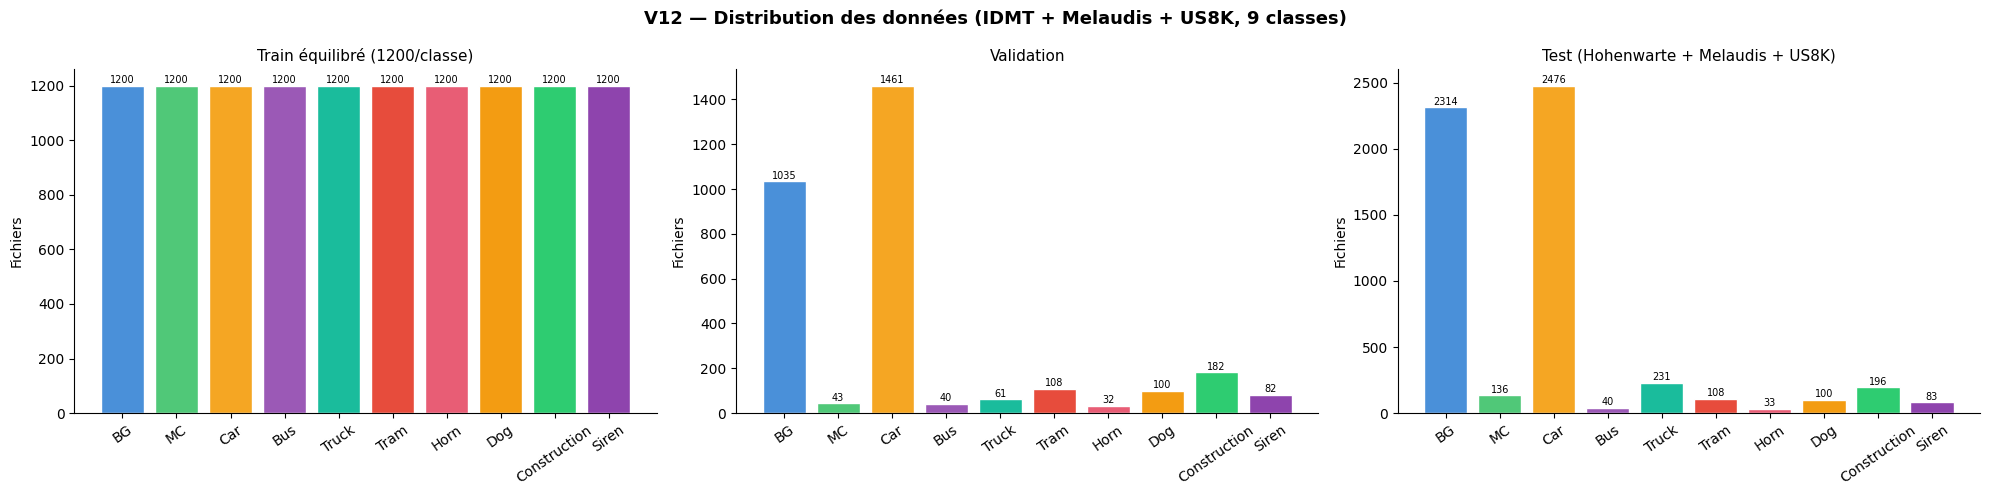


Proportion par source dans le train set :
  idmt        :  2138 (17.8%)
  melaudis    :  5062 (42.2%)
  us8k        :  4800 (40.0%)


In [ ]:
colors = ['#4A90D9', '#50C878', '#F5A623', '#9B59B6', '#1ABC9C',
          '#E74C3C', '#E85D75', '#F39C12', '#2ECC71', '#8E44AD']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

datasets = [
    (train_files, f'Balanced train ({TARGET_PER_CLASS}/class)'),
    (val_files,   'Validation'),
    (test_files,  'Test (Hohenwarte + Melaudis + US8K)'),
]

for ax, (dset, title) in zip(axes, datasets):
    cnt = Counter(lbl for _, lbl, _ in dset)
    lbls = [CLASS_NAMES[i] for i in sorted(cnt)]
    vals = [cnt[i] for i in sorted(cnt)]
    bars = ax.bar(lbls, vals, color=colors[:len(lbls)], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                str(v), ha='center', va='bottom', fontsize=7)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Files')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', rotation=35)

# Source breakdown in the train set
plt.suptitle('V12 — Data Distribution (IDMT + Melaudis + US8K, 9 classes)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'distribution_v12.png'), dpi=150, bbox_inches='tight')
plt.show()

# Proportion by source in the train set
print('\nProportion by source in the train set:')
c_src = Counter(src for _, _, src in train_files)
for src, n in sorted(c_src.items()):
    pct = n / len(train_files) * 100
    print(f'  {src:12s}: {n:5d} ({pct:.1f}%)')

## 8. Audio Pipeline → Enriched Features (V12)

Same as V11 — 182 dimensions per timestep.

**RMS** normalization aligns the 3 datasets, which have different microphone gains.

| Feature | Dim | Role |
|---|---|---|
| **Mel spectrogram** | 128 | Global spectral profile |
| **MFCC** | 40 | Timbre and sound texture |
| **Chroma** | 12 | Tonality — fixed engine regimes |
| **ZCR** | 1 | Signal roughness |
| **RMS energy** | 1 | Instantaneous energy |

**US8K note**: US8K files are short clips of ~4s — the 2s window
applies directly without additional slicing.

In [ ]:
TARGET_RMS = 0.05

def normalize_rms(audio, target_rms=TARGET_RMS, eps=1e-8):
    """RMS normalization — robust to inter-dataset gain variations."""
    rms = np.sqrt(np.mean(audio ** 2))
    if rms < eps:
        return audio
    return audio * (target_rms / rms)


def wav_to_features(wav_path, offset=0.0, duration=None,
                    target_time_steps=TIME_STEPS, rich=True):
    """
    WAV → enriched features (time_steps, FEATURE_DIM) as float32.
    Compatible with IDMT, Melaudis and US8K.
    """
    try:
        audio, sr = librosa.load(
            wav_path, sr=TARGET_SR, mono=True,
            offset=offset, duration=duration
        )
        if len(audio) < FRAME_SIZE:
            return None
        audio = normalize_rms(audio)

        # ── Mel spectrogram
        mel = librosa.feature.melspectrogram(
            y=audio, sr=TARGET_SR, n_fft=FRAME_SIZE, hop_length=HOP_SIZE,
            n_mels=N_MELS, fmin=20, fmax=8000
        )
        log_mel = librosa.power_to_db(mel, ref=np.max)
        mn, mx  = log_mel.min(), log_mel.max()
        log_mel = (log_mel - mn) / (mx - mn + 1e-8)   # (N_MELS, T)

        if not rich:
            seq = log_mel.T
        else:
            # ── MFCC
            mfcc = librosa.feature.mfcc(
                y=audio, sr=TARGET_SR, n_mfcc=N_MFCC,
                n_fft=FRAME_SIZE, hop_length=HOP_SIZE
            )
            mfcc = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (mfcc.std(axis=1, keepdims=True) + 1e-8)
            mfcc = np.clip(mfcc / 3.0, -1, 1) * 0.5 + 0.5

            # ── Chroma
            chroma = librosa.feature.chroma_stft(
                y=audio, sr=TARGET_SR, n_fft=FRAME_SIZE, hop_length=HOP_SIZE
            )

            # ── ZCR
            zcr = librosa.feature.zero_crossing_rate(
                y=audio, frame_length=FRAME_SIZE, hop_length=HOP_SIZE
            )

            # ── RMS energy
            rms_feat = librosa.feature.rms(
                y=audio, frame_length=FRAME_SIZE, hop_length=HOP_SIZE
            )
            rms_feat = rms_feat / (rms_feat.max() + 1e-8)

            # ── Temporal alignment
            T = log_mel.shape[1]
            for feat in [mfcc, chroma, zcr, rms_feat]:
                if feat.shape[1] != T:
                    T = min(T, feat.shape[1])
            log_mel   = log_mel[:, :T]
            mfcc      = mfcc[:, :T]
            chroma    = chroma[:, :T]
            zcr       = zcr[:, :T]
            rms_feat  = rms_feat[:, :T]

            seq = np.concatenate([
                log_mel.T,
                mfcc.T,
                chroma.T,
                zcr.T,
                rms_feat.T
            ], axis=1)  # (T, FEATURE_DIM)

        # ── Centered padding / truncation
        T_cur = seq.shape[0]
        if T_cur > target_time_steps:
            start = (T_cur - target_time_steps) // 2
            seq   = seq[start:start + target_time_steps]
        elif T_cur < target_time_steps:
            pad = np.zeros((target_time_steps - T_cur, seq.shape[1]), dtype='float32')
            seq = np.vstack([seq, pad])

        return seq.astype('float32')

    except Exception as e:
        return None


print(f'Audio pipeline V12 defined.')
print(f'  SR={TARGET_SR} Hz | Window={WINDOW_SEC}s | Stride={OVERLAP_SEC}s')
print(f'  Features: {FEATURE_DIM} dims/timestep | Time steps: {TIME_STEPS}')

Pipeline audio V12 défini.
  SR=22050 Hz | Fenêtre=2.0s | Stride=1.0s
  Features : 182 dims/timestep | Time steps : 174


## 9. SpecAugment — On-the-fly Augmentation (V12)

Same as V11, applied to all 3 sources.

**For Horn (~386 files)**: ×3 oversampling + SpecAugment diversify the examples
enough to avoid overfitting.

In [ ]:
@tf.function
def spec_augment(mel_seq, training=False):
    """
    SpecAugment applied on the fly to (batch, time_steps, feature_dim).
    Time masking + frequency masking + gain variation + noise.
    """
    if not training:
        return mel_seq

    T = tf.shape(mel_seq)[1]
    F = tf.shape(mel_seq)[2]

    # ── Time masking (up to T//5)
    t_size  = tf.random.uniform([], 0, T // 5, dtype=tf.int32)
    t_start = tf.random.uniform([], 0, T - t_size, dtype=tf.int32)
    t_mask  = tf.concat([tf.ones([t_start]),
                          tf.zeros([t_size]),
                          tf.ones([T - t_start - t_size])], axis=0)
    mel_seq = mel_seq * tf.reshape(t_mask, [1, T, 1])

    # ── Frequency masking (up to F//8)
    f_size  = tf.random.uniform([], 0, F // 8, dtype=tf.int32)
    f_start = tf.random.uniform([], 0, F - f_size, dtype=tf.int32)
    f_mask  = tf.concat([tf.ones([1, T, f_start]),
                          tf.zeros([1, T, f_size]),
                          tf.ones([1, T, F - f_start - f_size])], axis=2)
    mel_seq = mel_seq * tf.cast(f_mask, mel_seq.dtype)

    # ── Gain variation
    gain    = tf.random.uniform([], 0.6, 1.4)
    mel_seq = mel_seq * gain

    # ── Additive noise
    noise   = tf.random.normal(tf.shape(mel_seq), stddev=0.008)
    mel_seq = tf.clip_by_value(mel_seq + noise, 0.0, 1.0)

    return mel_seq


print('V12 SpecAugment augmentations defined.')
print('  Time masking  : T // 5')
print('  Freq masking  : F // 8')
print('  Gain variation: [0.6, 1.4]')
print('  Additive noise: σ=0.008')

Augmentations SpecAugment V12 définies.
  Time masking  : T // 5
  Freq masking  : F // 8
  Gain variation: [0.6, 1.4]
  Bruit additif : σ=0.008


## 10. Loading into memory

In [ ]:
def load_dataset(file_list, desc='Loading', rich=True):
    """Loads a list (path, label, domain) → (X, y) numpy arrays."""
    seqs, labels = [], []
    errors = 0
    for wav_path, label, domain in tqdm(file_list, desc=desc):
        seq = wav_to_features(wav_path, duration=WINDOW_SEC, rich=rich)
        if seq is None:
            errors += 1
            continue
        seqs.append(seq)
        labels.append(label)
    print(f'  Loaded: {len(seqs)} | Errors: {errors}')
    return np.array(seqs, dtype='float32'), np.array(labels, dtype='int32')


t0 = time.time()
print('=== Loading TRAIN ===')
X_train_raw, y_train_raw = load_dataset(train_files, 'Train')

print('\n=== Loading VALIDATION ===')
X_val, y_val = load_dataset(val_files, 'Val')

print('\n=== Loading TEST ===')
X_test, y_test = load_dataset(test_files, 'Test')

elapsed = (time.time() - t0) / 60
print(f'\nTotal loading time: {elapsed:.1f} min')
print(f'Train shape: {X_train_raw.shape}  RAM: {X_train_raw.nbytes/1e6:.0f} MB')
print(f'Val   shape: {X_val.shape}')
print(f'Test  shape: {X_test.shape}')

=== Chargement TRAIN ===


Train:   0%|          | 0/12000 [00:00<?, ?it/s]

  Chargé: 12000 | Erreurs: 0

=== Chargement VALIDATION ===


Val:   0%|          | 0/3144 [00:00<?, ?it/s]

  Chargé: 3144 | Erreurs: 0

=== Chargement TEST ===


Test:   0%|          | 0/5717 [00:00<?, ?it/s]

  Chargé: 5717 | Erreurs: 0

Temps total chargement : 9.3 min
Train shape : (12000, 174, 182)  RAM: 1520 MB
Val   shape : (3144, 174, 182)
Test  shape : (5717, 174, 182)


In [ ]:
# ── Final shuffle of the train set
X_train, y_train = shuffle(X_train_raw, y_train_raw, random_state=SEED)
del X_train_raw, y_train_raw

print('Datasets ready:')
print(f'  Train      : {len(X_train):6d}  — {Counter(y_train.tolist())}')
print(f'  Validation : {len(X_val):6d}  — {Counter(y_val.tolist())}')
print(f'  Test       : {len(X_test):6d}  — {Counter(y_test.tolist())}')

# ── Source per example in the test set
test_sources = [src for _, _, src in test_files[:len(y_test)]]
src_counts = Counter(test_sources)
print(f'\nTest set by source: {dict(src_counts)}')

Datasets prêts :
  Train      :  12000  — Counter({4: 1200, 7: 1200, 2: 1200, 3: 1200, 9: 1200, 1: 1200, 8: 1200, 0: 1200, 6: 1200, 5: 1200})
  Validation :   3144  — Counter({2: 1461, 0: 1035, 8: 182, 5: 108, 7: 100, 9: 82, 4: 61, 1: 43, 3: 40, 6: 32})
  Test       :   5717  — Counter({2: 2476, 0: 2314, 4: 231, 8: 196, 1: 136, 5: 108, 7: 100, 9: 83, 3: 40, 6: 33})

Test set par source : {'idmt': 2857, 'melaudis': 2448, 'us8k': 412}


## 11. Pipelines tf.data

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(buffer_size=4096, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE)
    if training:
        ds = ds.map(
            lambda x, y: (spec_augment(x, training=True), y),
            num_parallel_calls=AUTOTUNE
        )
    return ds.prefetch(AUTOTUNE)


train_ds = make_dataset(X_train, y_train, training=True)
val_ds   = make_dataset(X_val,   y_val,   training=False)
test_ds  = make_dataset(X_test,  y_test,  training=False)

print('tf.data pipelines created.')
print(f'  Train: {len(train_ds)} batches | Val: {len(val_ds)} | Test: {len(test_ds)}')

Pipelines tf.data créés.
  Train : 375 batches | Val : 99 | Test : 179


## 12. V12 Architecture — CNN1D + BiLSTM + Self-Attention (9 classes)

Architecture identical to V11, adapted for **9 classes** instead of 7.

```text
Input (time_steps, FEATURE_DIM=182)
  → Masking (ignore zero padding)
  → BatchNorm
  → Conv1D(64,5,causal) + BN + Conv1D(128,3,causal) + BN → MaxPool(2)
  → Conv1D(256,3,causal) + BN → MaxPool(2)
  → Conv1D(256,3,causal) + BN + Dropout(0.2)
  → BiLSTM(128, return_seq=True)
  → BiLSTM(64,  return_seq=True)
  → MultiHeadAttention(4 heads, key_dim=32) + residual + LayerNorm
  → GlobalAveragePooling1D
  → Dropout(0.4) → Dense(256, relu) → Dropout(0.3) → Dense(9, softmax)

The final Dense layer changes from 7 → 9 outputs for the 4 new US8K classes.

In [ ]:
def build_model_v12(input_shape, num_classes=NUM_CLASSES):
    """
    V12: CNN1D × 3 + BiLSTM × 2 + Multi-Head Self-Attention — 9 classes.
    Added: Horn, Dog, Construction, Siren (US8K).
    Removed: Bicycle (→ BG).
    """
    inputs = keras.Input(shape=input_shape, name='features')

    x = layers.Masking(mask_value=0.0)(inputs)
    x = layers.BatchNormalization()(x)

    # ── CNN Block 1: fine local patterns
    x = layers.Conv1D(64,  kernel_size=5, padding='causal', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, kernel_size=3, padding='causal', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)

    # ── CNN Block 2: intermediate patterns
    x = layers.Conv1D(256, kernel_size=3, padding='causal', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)

    # ── CNN Block 3: higher-level patterns
    x = layers.Conv1D(256, kernel_size=3, padding='causal', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    # ── BiLSTM: long-term temporal dependencies
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.1, recurrent_dropout=0.1)
    )(x)
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.1)
    )(x)

    # ── Multi-Head Self-Attention
    attn_out = layers.MultiHeadAttention(
        num_heads=4, key_dim=32, dropout=0.1, name='self_attention'
    )(x, x)
    x = layers.Add()([x, attn_out])       # residual connection
    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)

    # ── Classifier — 9 classes
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='CNN1D_BiLSTM_Attention_V12')


actual_shape = X_train.shape[1:]
model = build_model_v12(actual_shape)
model.summary()
print(f'\nParameters: {model.count_params():,}')
print(f'Input shape: {actual_shape}')
print(f'Num classes: {NUM_CLASSES} — {CLASS_LABELS_LIST}')

Model: "CNN1D_BiLSTM_Attention_V12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ features            │ (None, 174, 182)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 174, 182)  │          0 │ features[0][0]    │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 174, 182)  │          0 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 174)       │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 174, 182)  │        728 │ masking[0][0],    │
│ (BatchNormalizatio… │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 174, 64)   │     58,304 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 174, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 174, 128)  │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 174, 128)  │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 87, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 87, 256)   │     98,560 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 87, 256)   │      1,024 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 43, 256)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 43, 256)   │    196,864 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 43, 256)   │      1,024 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 43, 256)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 43, 256)   │    394,240 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 43, 128)   │    164,352 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 43, 128)   │     66,048 │ bidirectional_1[… │
│ (MultiHeadAttentio… │                   │            │ bidirectional_1[

 Total params: 1,042,466 (3.98 MB)

 Trainable params: 1,040,694 (3.97 MB)

 Non-trainable params: 1,772 (6.92 KB)


Paramètres : 1,042,466
Input shape : (174, 182)
Num classes : 10 — ['BG', 'MC', 'Car', 'Bus', 'Truck', 'Tram', 'Horn', 'Dog', 'Construction', 'Siren']


## 13. Warmup + Cosine Decay Scheduler & Compilation

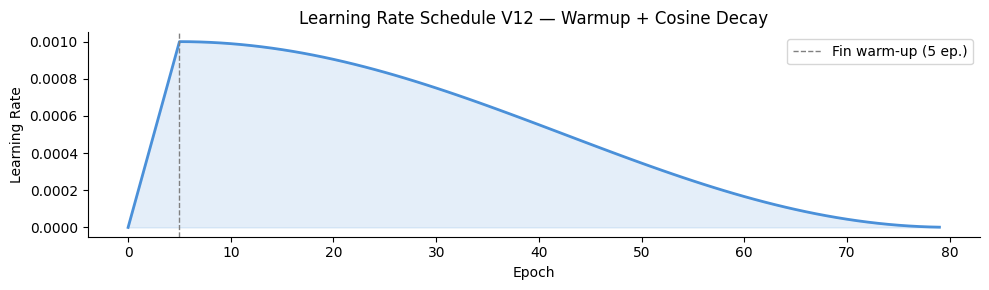

In [ ]:
class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    """Linear warmup (5 epochs), then cosine decay."""
    def __init__(self, max_lr, warmup_steps, total_steps, min_lr=1e-6):
        self.max_lr       = max_lr
        self.warmup_steps = warmup_steps
        self.total_steps  = total_steps
        self.min_lr       = min_lr

    def __call__(self, step):
        step   = tf.cast(step, tf.float32)
        wu     = tf.cast(self.warmup_steps, tf.float32)
        total  = tf.cast(self.total_steps,  tf.float32)
        warmup = self.max_lr * step / tf.maximum(wu, 1.0)
        cosine = self.min_lr + 0.5 * (self.max_lr - self.min_lr) * (
            1.0 + tf.cos(np.pi * (step - wu) / tf.maximum(total - wu, 1.0)))
        return tf.where(step < wu, warmup, cosine)

    def get_config(self):
        return dict(max_lr=self.max_lr, warmup_steps=self.warmup_steps,
                    total_steps=self.total_steps, min_lr=self.min_lr)


steps_per_epoch = len(train_ds)
total_steps     = EPOCHS * steps_per_epoch
warmup_steps    = 5 * steps_per_epoch

lr_schedule = WarmupCosineDecay(
    max_lr=LR_INIT, warmup_steps=warmup_steps,
    total_steps=total_steps, min_lr=1e-6
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ── LR schedule visualization
lrs = [float(lr_schedule(i * steps_per_epoch)) for i in range(EPOCHS)]
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(lrs, color='#4A90D9', lw=2)
ax.fill_between(range(EPOCHS), lrs, alpha=0.15, color='#4A90D9')
ax.axvline(5, color='gray', ls='--', lw=1, label='End of warm-up (5 ep.)')
ax.set_title('Learning Rate Schedule V12 — Warmup + Cosine Decay', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

## 14. Training

In [ ]:
best_model_path = os.path.join(RESULTS_DIR, 'best_model_v12.keras')

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=15, min_delta=0.002,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        best_model_path, monitor='val_accuracy',
        save_best_only=True, verbose=0
    ),
]

print(f'Starting V12 training')
print(f'  Dataset   : IDMT-Traffic + Melaudis + UrbanSound8K ({NUM_CLASSES} classes)')
print(f'  Features  : Mel + MFCC + Chroma + ZCR + RMS ({FEATURE_DIM} dims)')
print(f'  Arch      : CNN1D × 3 → BiLSTM × 2 → MultiHeadAttention → Dense')
print(f'  Augment   : SpecAugment (T//5, F//8) + gain [0.6, 1.4] + noise σ=0.008')
print(f'  Optimizer : Adam (Warmup+CosineDecay, clipnorm=1.0)')
print(f'  New items : Bicycle→BG | Horn, Dog, Construction, Siren from US8K')
print()

t0 = time.time()
history = model.fit(
    train_ds, epochs=EPOCHS, validation_data=val_ds,
    callbacks=callbacks, verbose=1
)
elapsed = (time.time() - t0) / 60
print(f'\n✅ Training completed in {elapsed:.1f} min')
print(f'   Actual epochs        : {len(history.history["accuracy"])}')
print(f'   Best val_acc         : {max(history.history["val_accuracy"])*100:.2f}%')

Démarrage entraînement V12
  Dataset   : IDMT-Traffic + Melaudis + UrbanSound8K (10 classes)
  Features  : Mel + MFCC + Chroma + ZCR + RMS (182 dims)
  Archi     : CNN1D × 3 → BiLSTM × 2 → MultiHeadAttention → Dense
  Augment   : SpecAugment (T//5, F//8) + gain [0.6, 1.4] + bruit σ=0.008
  Optimizer : Adam (Warmup+CosineDecay, clipnorm=1.0)
  Nouveautés: Bicycle→BG | Horn, Dog, Construction, Siren depuis US8K

Epoch 1/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 888s 2s/step - accuracy: 0.4385 - loss: 1.6379 - val_accuracy: 0.4870 - val_loss: 1.4466
Epoch 2/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 46s 123ms/step - accuracy: 0.6802 - loss: 0.9826 - val_accuracy: 0.6858 - val_loss: 0.9753
Epoch 3/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 218ms/step - accuracy: 0.7262 - loss: 0.8287 - val_accuracy: 0.5363 - val_loss: 1.3604
Epoch 4/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 116ms/step - accuracy: 0.7412 - loss: 0.7815 - val_accuracy: 0.5919 - val_loss: 1.3414
Epoch 5/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 48s 127ms/step - accurac

## 15. Learning Curves

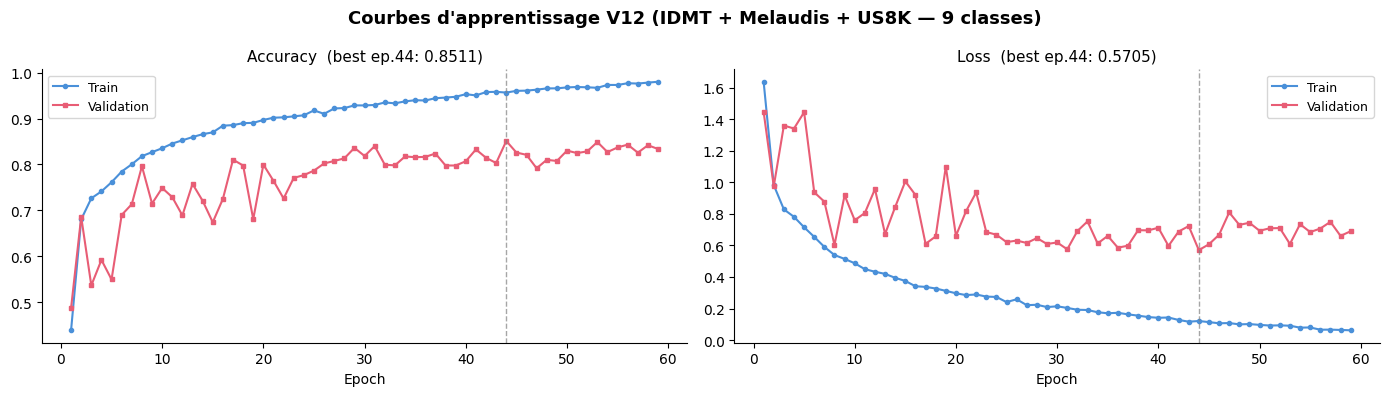

In [ ]:
ep = range(1, len(history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric, title in zip(axes,
    ['accuracy', 'loss'],
    ['Accuracy', 'Loss']):

    train_vals = history.history[metric]
    val_vals   = history.history[f'val_{metric}']

    if metric == 'accuracy':
        best_ep  = np.argmax(val_vals) + 1
        best_val = max(val_vals)
    else:
        best_ep  = np.argmin(val_vals) + 1
        best_val = min(val_vals)

    ax.plot(ep, train_vals, 'o-', color='#4A90D9', label='Train', lw=1.5, ms=3)
    ax.plot(ep, val_vals,   's-', color='#E85D75', label='Validation', lw=1.5, ms=3)
    ax.axvline(best_ep, color='gray', ls='--', lw=1, alpha=0.7)
    ax.set_title(f'{title}  (best ep.{best_ep}: {best_val:.4f})', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle("V12 Learning Curves (IDMT + Melaudis + US8K — 9 classes)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'learning_curves_v12.png'), dpi=150, bbox_inches='tight')
plt.show()

## 16. Evaluation — Global Test Set

In [ ]:
# ── Load the best model
model = keras.models.load_model(best_model_path, compile=False)
model.compile(
    optimizer=keras.optimizers.Adam(clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f'Test Accuracy (global): {test_acc*100:.2f}%')
print(f'Test Loss             : {test_loss:.4f}\n')

y_pred_proba = model.predict(test_ds, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

print(classification_report(
    y_test, y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_LABELS_LIST,
    zero_division=0
))

Test Accuracy (global) : 79.27%
Test Loss              : 0.7565

              precision    recall  f1-score   support

          BG       0.95      0.77      0.85      2314
          MC       0.84      0.89      0.86       136
         Car       0.88      0.80      0.84      2476
         Bus       0.49      0.85      0.62        40
       Truck       0.29      0.70      0.41       231
        Tram       0.73      0.94      0.82       108
        Horn       0.88      0.91      0.90        33
         Dog       0.72      0.91      0.81       100
Construction       0.54      0.91      0.68       196
       Siren       0.27      0.65      0.39        83

    accuracy                           0.79      5717
   macro avg       0.66      0.83      0.72      5717
weighted avg       0.86      0.79      0.81      5717



### 16b. Evaluation by Data Source

In [ ]:
for source in ['idmt', 'melaudis', 'us8k']:
    mask = np.array([s == source for s in test_sources])
    if mask.sum() == 0:
        continue
    yt  = y_test[mask]
    yp  = y_pred[mask]
    acc = (yt == yp).mean() * 100
    # Classes present in this subset
    present = sorted(set(yt.tolist()))
    present_names = [CLASS_LABELS_LIST[i] for i in present]
    print(f'\n── Source: {source.upper()} ({mask.sum()} examples) — Accuracy: {acc:.2f}%')
    print(classification_report(
        yt, yp,
        labels=present,
        target_names=present_names,
        zero_division=0
    ))


── Source : IDMT (2857 exemples) — Accuracy: 74.24%
              precision    recall  f1-score   support

          BG       1.00      0.75      0.86      1412
          MC       0.98      0.98      0.98        99
         Car       0.85      0.71      0.77      1157
       Truck       0.29      0.73      0.42       189

   micro avg       0.81      0.74      0.78      2857
   macro avg       0.78      0.79      0.76      2857
weighted avg       0.89      0.74      0.80      2857


── Source : MELAUDIS (2448 exemples) — Accuracy: 84.03%
              precision    recall  f1-score   support

          BG       0.92      0.80      0.85       902
          MC       0.53      0.65      0.59        37
         Car       0.91      0.88      0.89      1319
         Bus       0.49      0.85      0.62        40
       Truck       0.28      0.55      0.37        42
        Tram       0.78      0.94      0.85       108

   micro avg       0.86      0.84      0.85      2448
   macro avg       0.

## 17. Confusion Matrix

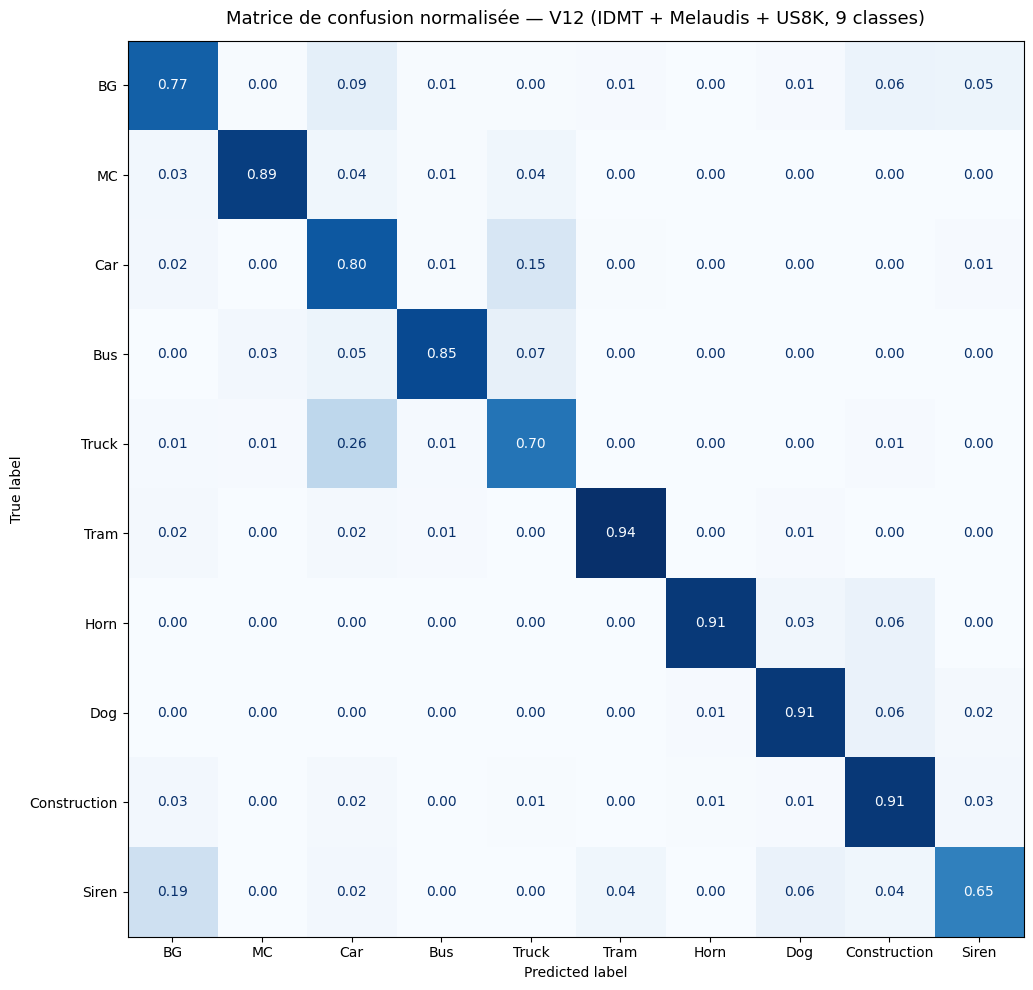


F1-score par classe :
  BG          : 0.852  █████████████████████████  ✅
  MC          : 0.864  █████████████████████████  ✅
  Car         : 0.837  █████████████████████████  ✅
  Bus         : 0.624  ██████████████████  ⚠️ 
  Truck       : 0.408  ████████████  ❌
  Tram        : 0.823  ████████████████████████  ✅
  Horn        : 0.896  ██████████████████████████  ✅
  Dog         : 0.805  ████████████████████████  ✅
  Construction: 0.678  ████████████████████  ⚠️ 
  Siren       : 0.386  ███████████  ❌
  macro avg   : 0.717


In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=list(range(NUM_CLASSES)), normalize='true')

fig, ax = plt.subplots(figsize=(11, 10))
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_LABELS_LIST)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='.2f', colorbar=False)

ax.set_title('Normalized Confusion Matrix — V12 (IDMT + Melaudis + US8K, 9 classes)',
             fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix_v12.png'), dpi=150, bbox_inches='tight')
plt.show()

# F1-score by class
print('\nF1-score by class:')
from sklearn.metrics import f1_score
f1s = f1_score(y_test, y_pred, labels=list(range(NUM_CLASSES)),
               average=None, zero_division=0)
for i, (cls, f1) in enumerate(zip(CLASS_LABELS_LIST, f1s)):
    bar = '█' * int(f1 * 30)
    ok  = '✅' if f1 >= 0.80 else ('⚠️ ' if f1 >= 0.50 else '❌')
    print(f'  {cls:12s}: {f1:.3f}  {bar}  {ok}')
print(f'  macro avg   : {f1s.mean():.3f}')

## 18. Precision-Recall Curves by Class

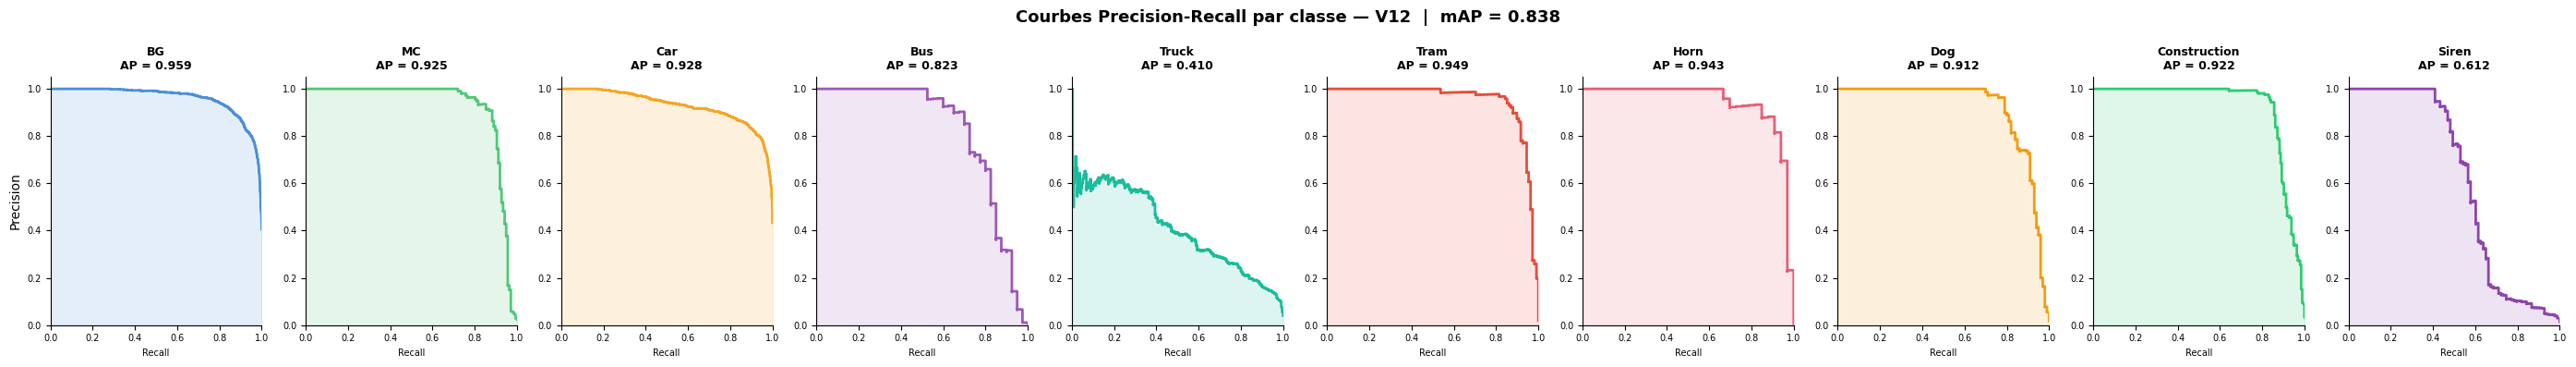


Average Precision par classe :
  BG          : 0.959  ████████████████████████████
  MC          : 0.925  ███████████████████████████
  Car         : 0.928  ███████████████████████████
  Bus         : 0.823  ████████████████████████
  Truck       : 0.410  ████████████
  Tram        : 0.949  ████████████████████████████
  Horn        : 0.943  ████████████████████████████
  Dog         : 0.912  ███████████████████████████
  Construction: 0.922  ███████████████████████████
  Siren       : 0.612  ██████████████████
  mAP        : 0.838


In [ ]:
y_test_bin = label_binarize(y_test, classes=list(range(NUM_CLASSES)))

colors_pr = ['#4A90D9', '#50C878', '#F5A623', '#9B59B6', '#1ABC9C',
             '#E74C3C', '#E85D75', '#F39C12', '#2ECC71', '#8E44AD']

n_cols = NUM_CLASSES
fig, axes = plt.subplots(1, n_cols, figsize=(n_cols * 2.8, 4))

ap_scores = {}
for i, (cls_name, clr) in enumerate(zip(CLASS_LABELS_LIST, colors_pr)):
    if y_test_bin[:, i].sum() == 0:
        ap_scores[cls_name] = 0.0
        axes[i].set_title(f'{cls_name}\nAP = N/A', fontsize=9)
        continue
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i], y_pred_proba[:, i]
    )
    ap = average_precision_score(y_test_bin[:, i], y_pred_proba[:, i])
    ap_scores[cls_name] = ap

    axes[i].step(recall, precision, where='post', color=clr, lw=2)
    axes[i].fill_between(recall, precision, alpha=0.15, color=clr, step='post')
    axes[i].set_title(f'{cls_name}\nAP = {ap:.3f}', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Recall', fontsize=7)
    if i == 0: axes[i].set_ylabel('Precision')
    axes[i].set_xlim([0, 1]); axes[i].set_ylim([0, 1.05])
    axes[i].spines[['top', 'right']].set_visible(False)
    axes[i].tick_params(labelsize=7)

valid_ap = [v for v in ap_scores.values() if v > 0]
mean_ap  = np.mean(valid_ap) if valid_ap else 0.0
plt.suptitle(
    f'Precision-Recall Curves by Class — V12  |  mAP = {mean_ap:.3f}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'pr_curves_v12.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAverage Precision by class:')
for cls, ap in ap_scores.items():
    bar = '█' * int(ap * 30)
    print(f'  {cls:12s}: {ap:.3f}  {bar}')
print(f'  mAP        : {mean_ap:.3f}')

## 19. t-SNE Visualization of Embeddings

3 panels:
1. Ground truth — clusters by class
2. Predictions — errors (red crosses) at the boundaries
3. Source — IDMT / Melaudis / US8K alignment

In [ ]:
# ── Embedding extraction (Dense(256) layer)
embedding_model = keras.Model(
    inputs=model.input,
    outputs=model.get_layer(index=-2).output
)

n_tsne    = min(2000, len(X_test))
idx_tsne  = np.random.choice(len(X_test), n_tsne, replace=False)
X_tsne_in = X_test[idx_tsne]
y_tsne_t  = y_test[idx_tsne]
y_tsne_p  = y_pred[idx_tsne]
src_tsne  = np.array(test_sources)[idx_tsne]

print(f'Extracting embeddings ({n_tsne} examples)...')
embeddings = embedding_model.predict(X_tsne_in, batch_size=128, verbose=0)
print(f'Embedding shape: {embeddings.shape}')

print('Running t-SNE (please be patient ~30-60s)...')
t0 = time.time()
tsne   = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=SEED)
emb_2d = tsne.fit_transform(embeddings)
print(f'  t-SNE completed in {time.time()-t0:.1f}s')

Extraction embeddings (2000 exemples)...
Embedding shape : (2000, 256)
t-SNE en cours (patience ~30-60s)...
  t-SNE terminé en 9.1s


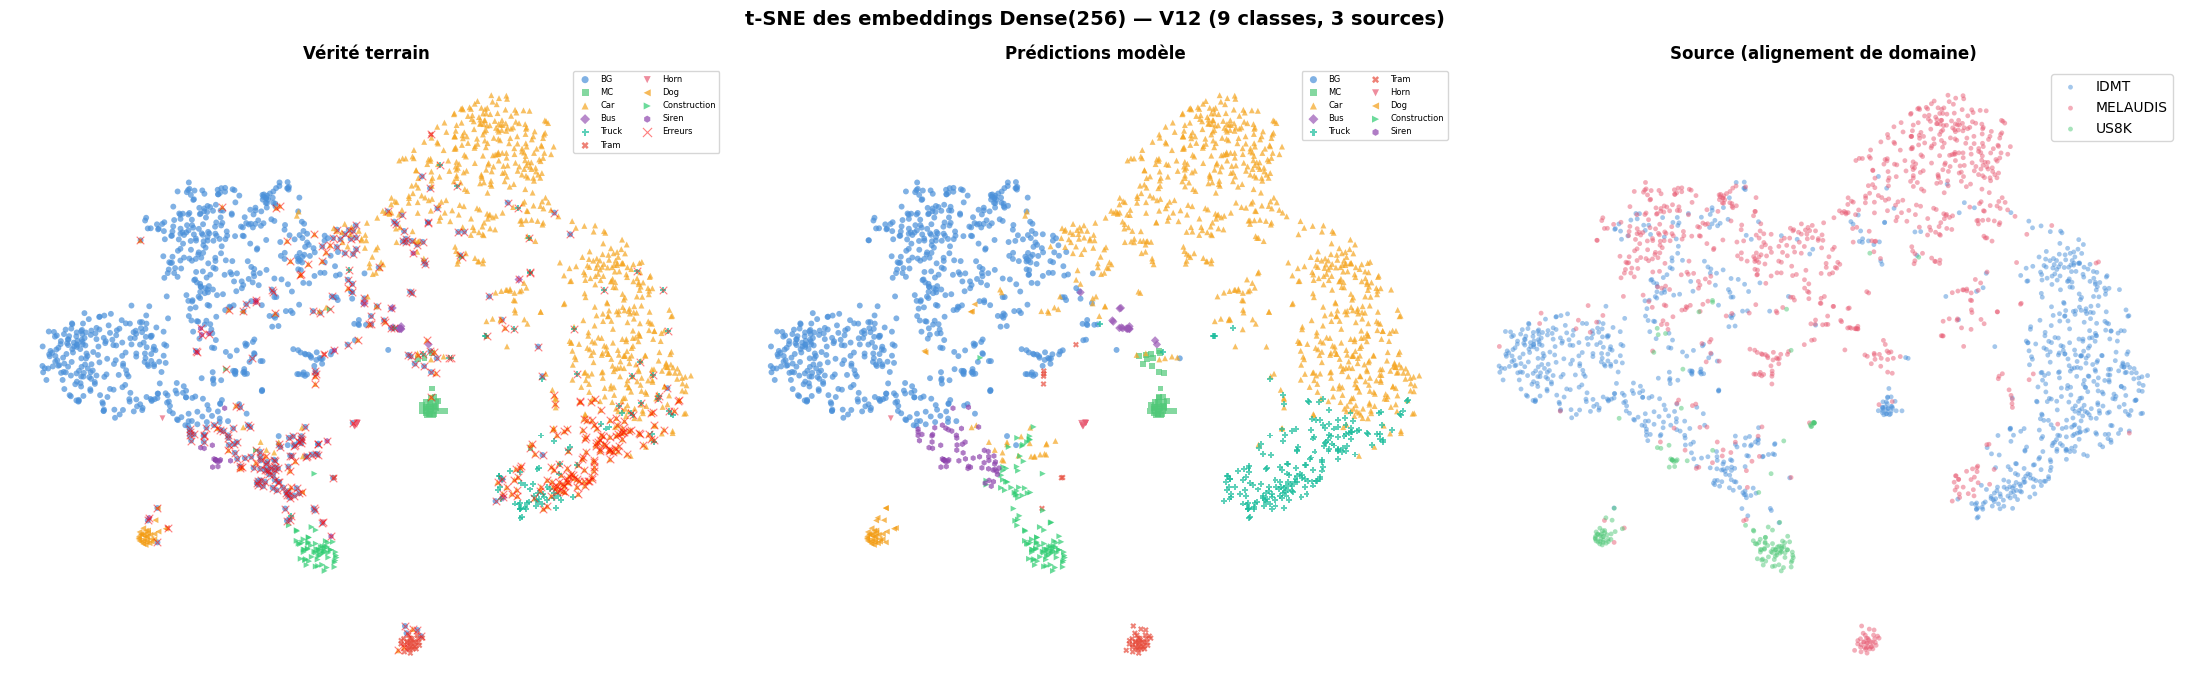

In [ ]:
markers = ['o', 's', '^', 'D', 'P', 'X', 'v', '<', '>', 'h']

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ── Panel 1: ground truth
for cls_idx, (cls_name, clr, mk) in enumerate(zip(CLASS_LABELS_LIST, colors_pr, markers)):
    mask = y_tsne_t == cls_idx
    axes[0].scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    c=clr, marker=mk, s=18, alpha=0.7, label=cls_name, edgecolors='none')
err_mask = y_tsne_t != y_tsne_p
axes[0].scatter(emb_2d[err_mask, 0], emb_2d[err_mask, 1],
                c='red', s=30, alpha=0.5, marker='x', label='Errors', linewidths=0.8)
axes[0].set_title('Ground truth', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=6, markerscale=1.2, ncol=2)

# ── Panel 2: predictions
for cls_idx, (cls_name, clr, mk) in enumerate(zip(CLASS_LABELS_LIST, colors_pr, markers)):
    mask = y_tsne_p == cls_idx
    axes[1].scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    c=clr, marker=mk, s=18, alpha=0.7, label=cls_name, edgecolors='none')
axes[1].set_title('Model predictions', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=6, markerscale=1.2, ncol=2)

# ── Panel 3: source (domain alignment — 3 sources in V12)
src_colors = {'idmt': '#4A90D9', 'melaudis': '#E85D75', 'us8k': '#50C878'}
for src, clr in src_colors.items():
    mask = src_tsne == src
    if mask.sum() > 0:
        axes[2].scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                        c=clr, s=12, alpha=0.5, label=src.upper(), edgecolors='none')
axes[2].set_title('Source (domain alignment)', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

plt.suptitle('t-SNE of Dense(256) embeddings — V12 (9 classes, 3 sources)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'tsne_v12.png'), dpi=150, bbox_inches='tight')
plt.show()

## 20. Self-Attention Heatmaps by Class

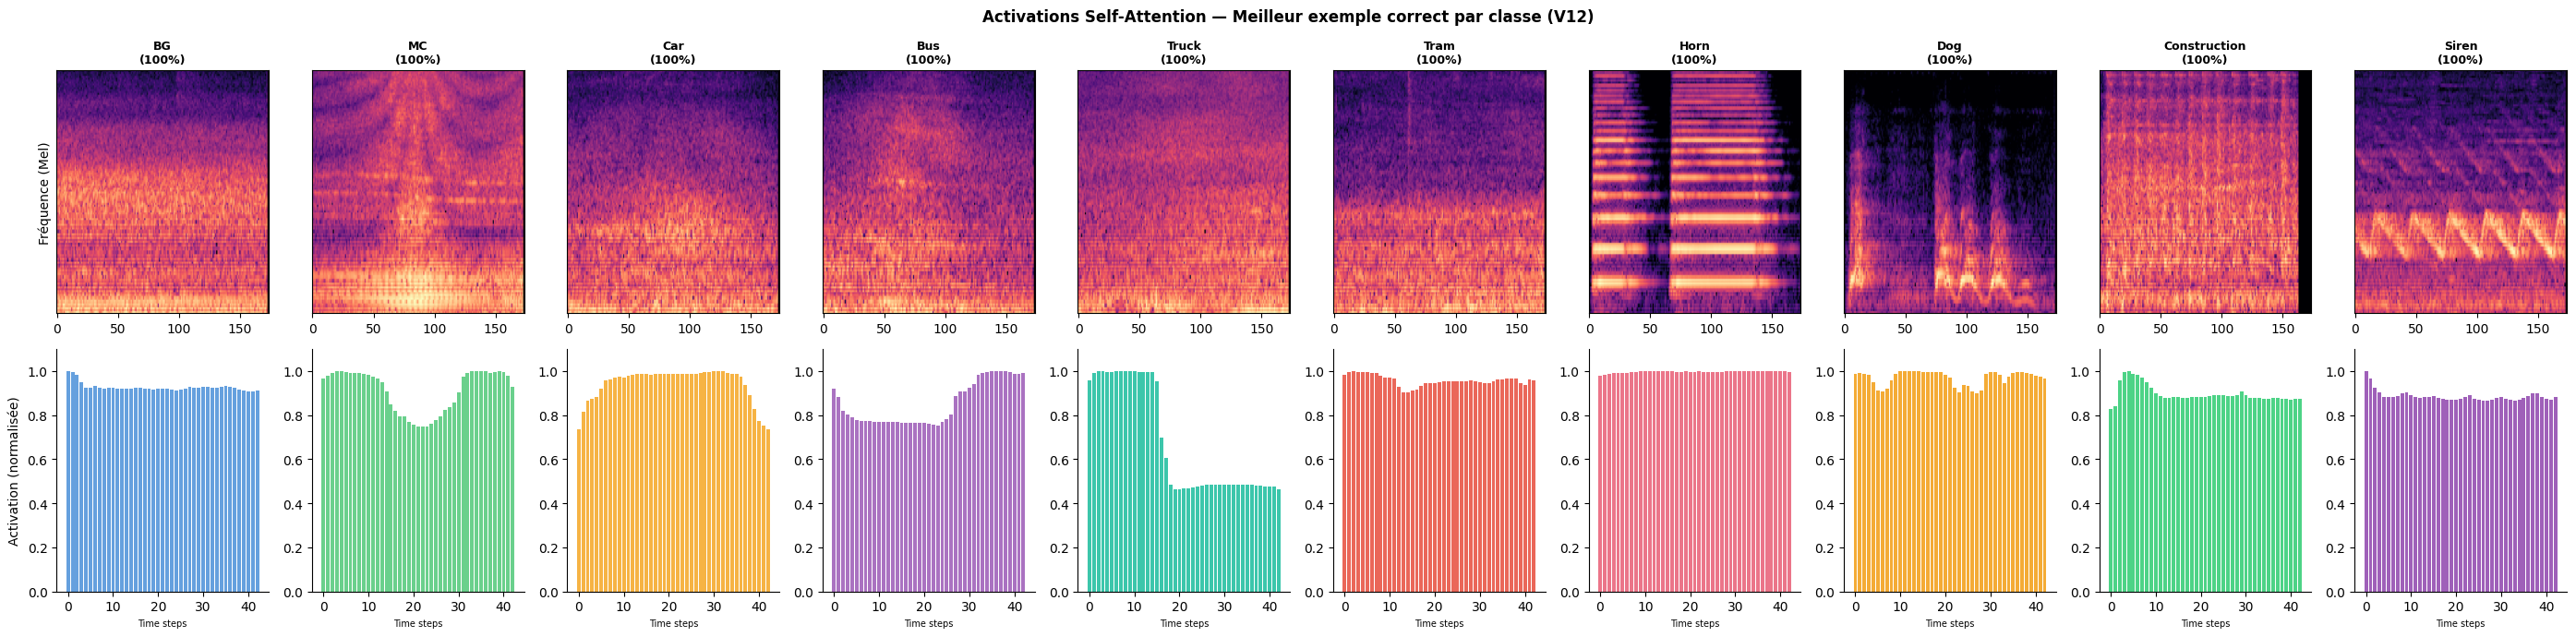

In [ ]:
attention_model = keras.Model(
    inputs=model.input,
    outputs=model.get_layer('self_attention').output
)

n_cols = NUM_CLASSES
fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 2.8, 7))
fig.suptitle('Self-Attention Activations — Best Correct Example per Class (V12)',
             fontsize=12, fontweight='bold')

for cls_idx in range(NUM_CLASSES):
    cls_name     = CLASS_NAMES[cls_idx]
    correct_mask = (y_test == cls_idx) & (y_pred == cls_idx)

    if not correct_mask.any():
        axes[0][cls_idx].set_title(f'{cls_name}\n(absent)', fontsize=8)
        axes[0][cls_idx].set_visible(False)
        axes[1][cls_idx].set_visible(False)
        continue

    correct_idx = np.where(correct_mask)[0]
    best_idx    = correct_idx[np.argmax(y_pred_proba[correct_idx, cls_idx])]

    # Mel
    mel_data = X_test[best_idx, :, :N_MELS].T
    axes[0][cls_idx].imshow(mel_data, aspect='auto', origin='lower', cmap='magma')
    axes[0][cls_idx].set_title(
        f'{cls_name}\n({y_pred_proba[best_idx, cls_idx]*100:.0f}%)',
        fontsize=9, fontweight='bold'
    )
    axes[0][cls_idx].set_yticks([])
    if cls_idx == 0: axes[0][cls_idx].set_ylabel('Frequency (Mel)')

    # Attention activation
    inp       = X_test[best_idx:best_idx+1]
    attn_out  = attention_model.predict(inp, verbose=0)
    attn_nrg  = np.abs(attn_out[0]).mean(axis=1)
    attn_nrg /= attn_nrg.max() + 1e-8

    axes[1][cls_idx].bar(range(len(attn_nrg)), attn_nrg,
                          color=colors_pr[cls_idx], edgecolor='none', alpha=0.85)
    axes[1][cls_idx].set_ylim(0, 1.1)
    axes[1][cls_idx].set_xlabel('Time steps', fontsize=7)
    if cls_idx == 0: axes[1][cls_idx].set_ylabel('Activation (normalized)')
    axes[1][cls_idx].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'attention_heatmap_v12.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 21. Error Analysis

In [ ]:
errors_mask   = y_pred != y_test
error_indices = np.where(errors_mask)[0]
error_confs   = y_pred_proba[error_indices].max(axis=1)

print(f'Total errors: {errors_mask.sum()} / {len(y_test)} '
      f'({errors_mask.mean()*100:.1f}%)')

err_df = pd.DataFrame({
    'true'      : [CLASS_NAMES[y_test[i]] for i in error_indices],
    'pred'      : [CLASS_NAMES[y_pred[i]] for i in error_indices],
    'confidence': (error_confs * 100).round(1),
    'source'    : [test_sources[i] if i < len(test_sources) else 'unknown'
                   for i in error_indices]
})

print('\nError matrix (true → predicted):')
pivot = err_df.groupby(['true', 'pred']).size().unstack(fill_value=0)
print(pivot)

print('\nErrors by source:')
print(err_df.groupby('source').size())

top_wrong_idx = error_indices[np.argsort(error_confs)[::-1][:10]]
print(f'\nTop-10 most confident errors:')
for i in top_wrong_idx:
    v   = CLASS_NAMES[y_test[i]]
    p   = CLASS_NAMES[y_pred[i]]
    c   = y_pred_proba[i].max() * 100
    src = test_sources[i] if i < len(test_sources) else '?'
    print(f'  idx={i:4d} | {src:10s} | true={v:12s} → predicted={p:12s} | confidence={c:.1f}%')

Erreurs totales : 1185 / 5717 (20.7%)

Matrice des erreurs (vrai → prédit) :
pred          BG  Bus  Car  Construction  Dog  Horn  MC  Siren  Tram  Truck
vrai                                                                       
BG             0   16  197           131   25     2  11    117    24      9
Bus            0    0    2             0    0     0   1      0     0      3
Car           56   14    0             9    1     0   9     19    11    379
Construction   5    0    3             0    2     1   0      5     0      1
Dog            0    0    0             6    0     1   0      2     0      0
Horn           0    0    0             2    1     0   0      0     0      0
MC             4    1    5             0    0     0   0      0     0      5
Siren         16    0    2             3    5     0   0      0     3      0
Tram           2    1    2             0    1     0   0      0     0      0
Truck          3    3   60             2    0     0   2      0     0      0

Erreurs pa

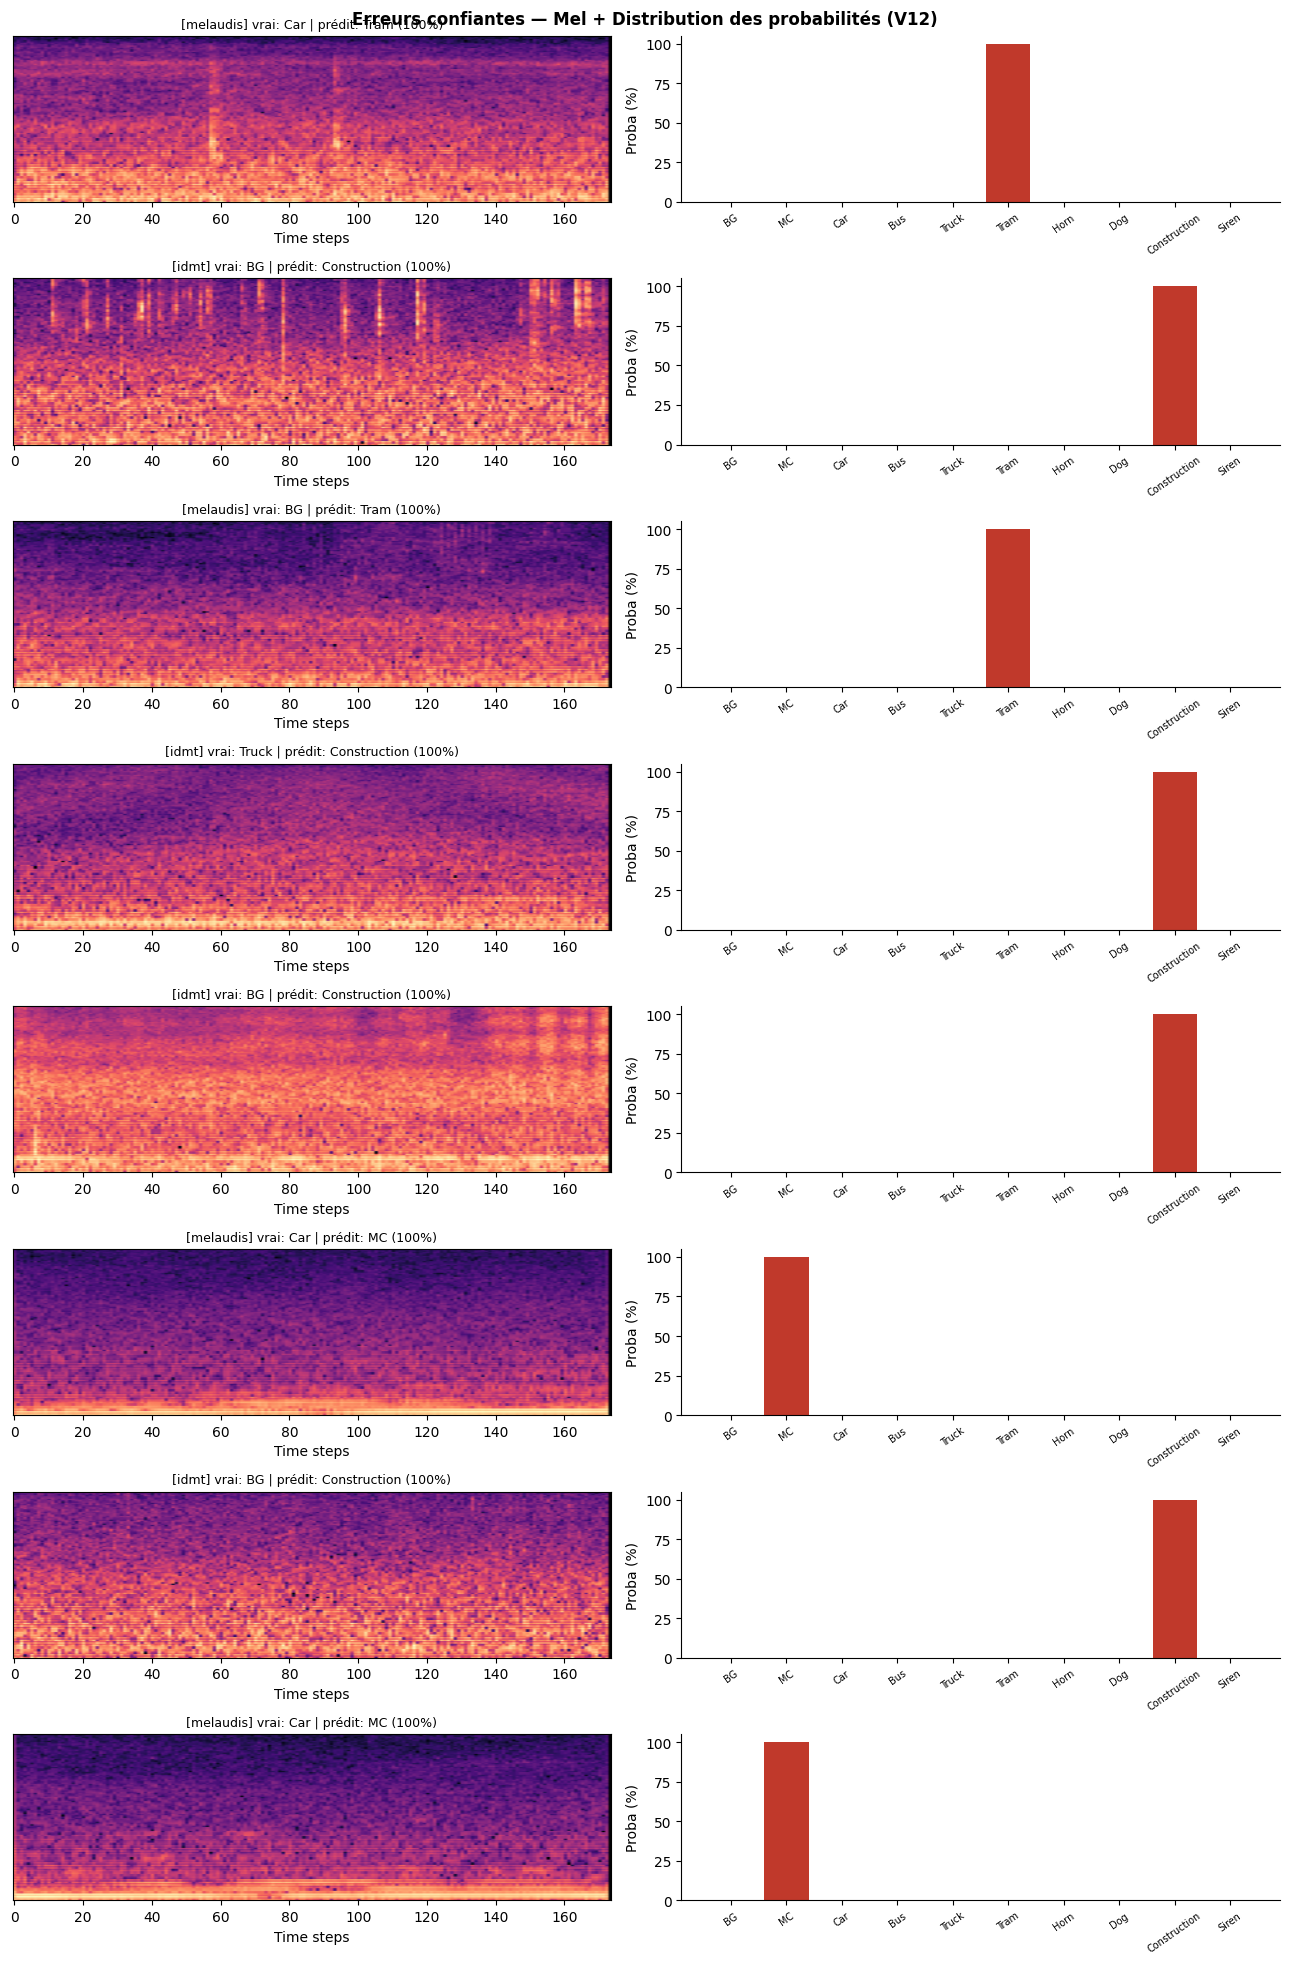

In [ ]:
# ── Visualization of confident errors
n_show = min(8, len(top_wrong_idx))
if n_show > 0:
    fig, axes = plt.subplots(n_show, 2, figsize=(13, n_show * 2.5))
    if n_show == 1:
        axes = axes[np.newaxis, :]

    for row, idx in enumerate(top_wrong_idx[:n_show]):
        v    = CLASS_NAMES[y_test[idx]]
        p    = CLASS_NAMES[y_pred[idx]]
        conf = y_pred_proba[idx].max() * 100
        src  = test_sources[idx] if idx < len(test_sources) else '?'

        mel_data = X_test[idx, :, :N_MELS].T
        axes[row, 0].imshow(mel_data, aspect='auto', origin='lower', cmap='magma')
        axes[row, 0].set_title(f'[{src}] true: {v} | predicted: {p} ({conf:.0f}%)',
                                fontsize=9)
        axes[row, 0].set_yticks([]); axes[row, 0].set_xlabel('Time steps')

        probs    = y_pred_proba[idx]
        bar_clrs = [colors_pr[j] for j in range(NUM_CLASSES)]
        true_idx = CLASS_TOKENS.get(v, -1)
        pred_idx = CLASS_TOKENS.get(p, -1)
        if true_idx >= 0: bar_clrs[true_idx] = '#2d6a4f'
        if pred_idx >= 0 and pred_idx != true_idx: bar_clrs[pred_idx] = '#c0392b'

        axes[row, 1].bar(CLASS_LABELS_LIST, probs * 100, color=bar_clrs, edgecolor='none')
        axes[row, 1].set_ylim(0, 105)
        axes[row, 1].set_ylabel('Probability (%)')
        axes[row, 1].tick_params(axis='x', rotation=35, labelsize=7)
        axes[row, 1].spines[['top', 'right']].set_visible(False)

    plt.suptitle('Confident errors — Mel + Probability distribution (V12)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'confident_errors_v12.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

## 22. Inference Engine — Personal Recordings

V12 pipeline: identical to V11 (2s windowing + energy-weighted voting).

**New detectable classes**: Horn, Dog, Construction, Siren.

In [ ]:
ENERGY_THRESHOLD     = 0.01
CONFIDENCE_THRESHOLD = 0.55
BG_LABEL             = 'BG'


def get_duration(wav_path):
    try:
        return librosa.get_duration(path=wav_path)
    except Exception:
        return 0.0


def predict_long_audio(wav_path, model, window_sec=WINDOW_SEC, overlap_sec=OVERLAP_SEC):
    """
    Windowed inference on an audio file of arbitrary length.
    Returns a complete dict with soft vote, energy vote, and timeline.
    """
    duration = get_duration(wav_path)
    if duration < 0.5:
        return None

    stride = window_sec - overlap_sec
    if duration <= window_sec:
        offsets = [0.0]
    else:
        offsets, t = [], 0.0
        while t + window_sec <= duration + 0.05:
            offsets.append(min(t, duration - window_sec))
            t += stride

    windows, raw_rms_list = [], []
    for offset in offsets:
        try:
            audio, _ = librosa.load(wav_path, sr=TARGET_SR, mono=True,
                                     offset=offset, duration=window_sec)
            raw_rms  = np.sqrt(np.mean(audio ** 2))
            raw_rms_list.append(raw_rms)
            seq = wav_to_features(wav_path, offset=offset, duration=window_sec, rich=True)
            windows.append(seq if seq is not None
                           else np.zeros((TIME_STEPS, FEATURE_DIM), dtype='float32'))
        except Exception:
            windows.append(np.zeros((TIME_STEPS, FEATURE_DIM), dtype='float32'))
            raw_rms_list.append(0.0)

    if not windows:
        return None

    raw_rms_arr = np.array(raw_rms_list)
    active_mask = raw_rms_arr >= ENERGY_THRESHOLD
    batch       = np.stack(windows, axis=0)
    all_probs   = model.predict(batch, verbose=0)

    bg_idx       = CLASS_TOKENS[BG_LABEL]
    non_bg_probs = all_probs.copy(); non_bg_probs[:, bg_idx] = 0.0
    best_non_bg  = non_bg_probs.max(axis=1)
    vehicle_mask = active_mask & (best_non_bg >= CONFIDENCE_THRESHOLD)
    n_vehicle    = int(vehicle_mask.sum())

    if n_vehicle > 0:
        weights       = best_non_bg[vehicle_mask]
        v_probs       = (all_probs[vehicle_mask] * weights[:, None]).sum(axis=0)
        v_probs[bg_idx] = 0.0
        v_probs      /= v_probs.sum() + 1e-8
        vehicle_pred  = CLASS_NAMES[np.argmax(v_probs)]
        vehicle_conf  = float(v_probs.max()) * 100
    else:
        vehicle_pred = BG_LABEL
        vehicle_conf = float(all_probs[:, bg_idx].mean()) * 100
        v_probs      = all_probs.mean(axis=0)

    soft_probs   = all_probs.mean(axis=0)
    soft_pred    = CLASS_NAMES[np.argmax(soft_probs)]
    soft_conf    = float(soft_probs.max()) * 100
    window_votes = Counter(CLASS_NAMES[np.argmax(p)] for p in all_probs)

    return {
        'duration_s'   : duration,
        'n_windows'    : len(windows),
        'n_active'     : int(active_mask.sum()),
        'n_vehicle'    : n_vehicle,
        'offsets'      : offsets,
        'soft_pred'    : soft_pred,
        'soft_conf'    : soft_conf,
        'energy_pred'  : vehicle_pred,
        'energy_conf'  : vehicle_conf,
        'window_votes' : dict(window_votes),
        'all_probs'    : all_probs,
        'soft_probs'   : soft_probs,
        'energy_probs' : v_probs,
        'active_mask'  : active_mask,
        'raw_rms'      : raw_rms_arr,
    }


print('V12 inference engine defined.')
print(f'  Detectable classes: {CLASS_LABELS_LIST}')

Moteur d'inférence V12 défini.
  Classes détectables : ['BG', 'MC', 'Car', 'Bus', 'Truck', 'Tram', 'Horn', 'Dog', 'Construction', 'Siren']


## 23. Inference on personal recordings

In [ ]:
# ══════════════════════════════════════════════════════════════
# Possible classes: BG, MC, Car, Bus, Truck, Tram,
#                   Horn, Dog, Construction, Siren
# ══════════════════════════════════════════════════════════════
GROUND_TRUTH = {
    '3cars.wav'       : 'Car',
    'car 2.wav'       : 'Car',
    'car-bus-car.wav' : 'Bus',
    'car3.wav'        : 'Car',
    'car4.wav'        : 'Car',
    'car5.wav'        : 'Car',
    'electric car.wav': 'BG',   # ← V12: electric car → BG
    'noaudio1.wav'    : 'BG',
    'noaudio2.wav'    : 'BG',
    'noaudio3.wav'    : 'BG',
    'noaudio4.wav'    : 'BG',
}

all_results    = {}
results_simple = []

print(f"{'File':<25} | {'Dur':>5} | {'Win':>3}/{'>3':>3} | "
      f"{'Soft':>12} {'%':>5} | {'Energy':>12} {'%':>5} | GT")
print('-' * 105)

for fname, true_cls in GROUND_TRUTH.items():
    wav_path = os.path.join(MY_AUDIO, fname)
    if not os.path.exists(wav_path):
        print(f'  ⚠️  Not found: {wav_path}')
        continue
    res = predict_long_audio(wav_path, model)
    if res is None:
        print(f'  ⚠️  Reading error: {fname}')
        continue

    all_results[fname] = res
    s_ok = '✅' if res['soft_pred']   == true_cls else '❌'
    e_ok = '✅' if res['energy_pred'] == true_cls else '❌'
    print(f"{fname:<25} | {res['duration_s']:>5.1f}s | "
          f"{res['n_windows']:>3}/{res['n_active']:>3} | "
          f"{s_ok}{res['soft_pred']:>12} {res['soft_conf']:>4.0f}% | "
          f"{e_ok}{res['energy_pred']:>12} {res['energy_conf']:>4.0f}% | {true_cls}")

    row = {
        'file'          : fname,
        'duration_s'    : round(res['duration_s'], 1),
        'n_windows'     : res['n_windows'],
        'n_active'      : res['n_active'],
        'ground_truth'  : true_cls,
        'pred_soft'     : res['soft_pred'],
        'conf_soft'     : round(res['soft_conf'], 1),
        'correct_soft'  : res['soft_pred'] == true_cls,
        'pred_energy'   : res['energy_pred'],
        'conf_energy'   : round(res['energy_conf'], 1),
        'correct_energy': res['energy_pred'] == true_cls,
    }
    for cls in CLASS_LABELS_LIST:
        row[f'p_{cls}'] = round(float(res['soft_probs'][CLASS_TOKENS[cls]]) * 100, 1)
    results_simple.append(row)

df_results = pd.DataFrame(results_simple)
if len(df_results) > 0:
    n_ok_soft   = df_results['correct_soft'].sum()
    n_ok_energy = df_results['correct_energy'].sum()
    n_total     = len(df_results)
    print(f'\n📊 Inference score: Soft={n_ok_soft}/{n_total} '
          f'({n_ok_soft/n_total*100:.1f}%) | '
          f'Energy={n_ok_energy}/{n_total} ({n_ok_energy/n_total*100:.1f}%)')

Fichier                   |   Dur | Fen/ >3 |         Soft     % |      Energie     % | GT
---------------------------------------------------------------------------------------------------------
3cars.wav                 |  11.6s |  10/  8 | ✅         Car   63% | ✅         Car   63% | Car
car 2.wav                 |  15.2s |  14/  5 | ❌          BG   57% | ✅         Car   96% | Car
car-bus-car.wav           |  14.2s |  13/ 11 | ❌       Truck   43% | ❌       Truck   59% | Bus
car3.wav                  |   7.4s |   6/  3 | ✅         Car   99% | ✅         Car  100% | Car
car4.wav                  |   6.8s |   5/  3 | ✅         Car   87% | ✅         Car   87% | Car
car5.wav                  |   6.5s |   5/  3 | ✅         Car  100% | ✅         Car  100% | Car
electric car.wav          |   6.5s |   5/  0 | ❌         Car   49% | ✅          BG   46% | BG
noaudio1.wav              |   9.0s |   8/  0 | ✅          BG   80% | ✅          BG   80% | BG
noaudio2.wav              |   7.5s |   6/  0 

## 24. Confidence timeline per file

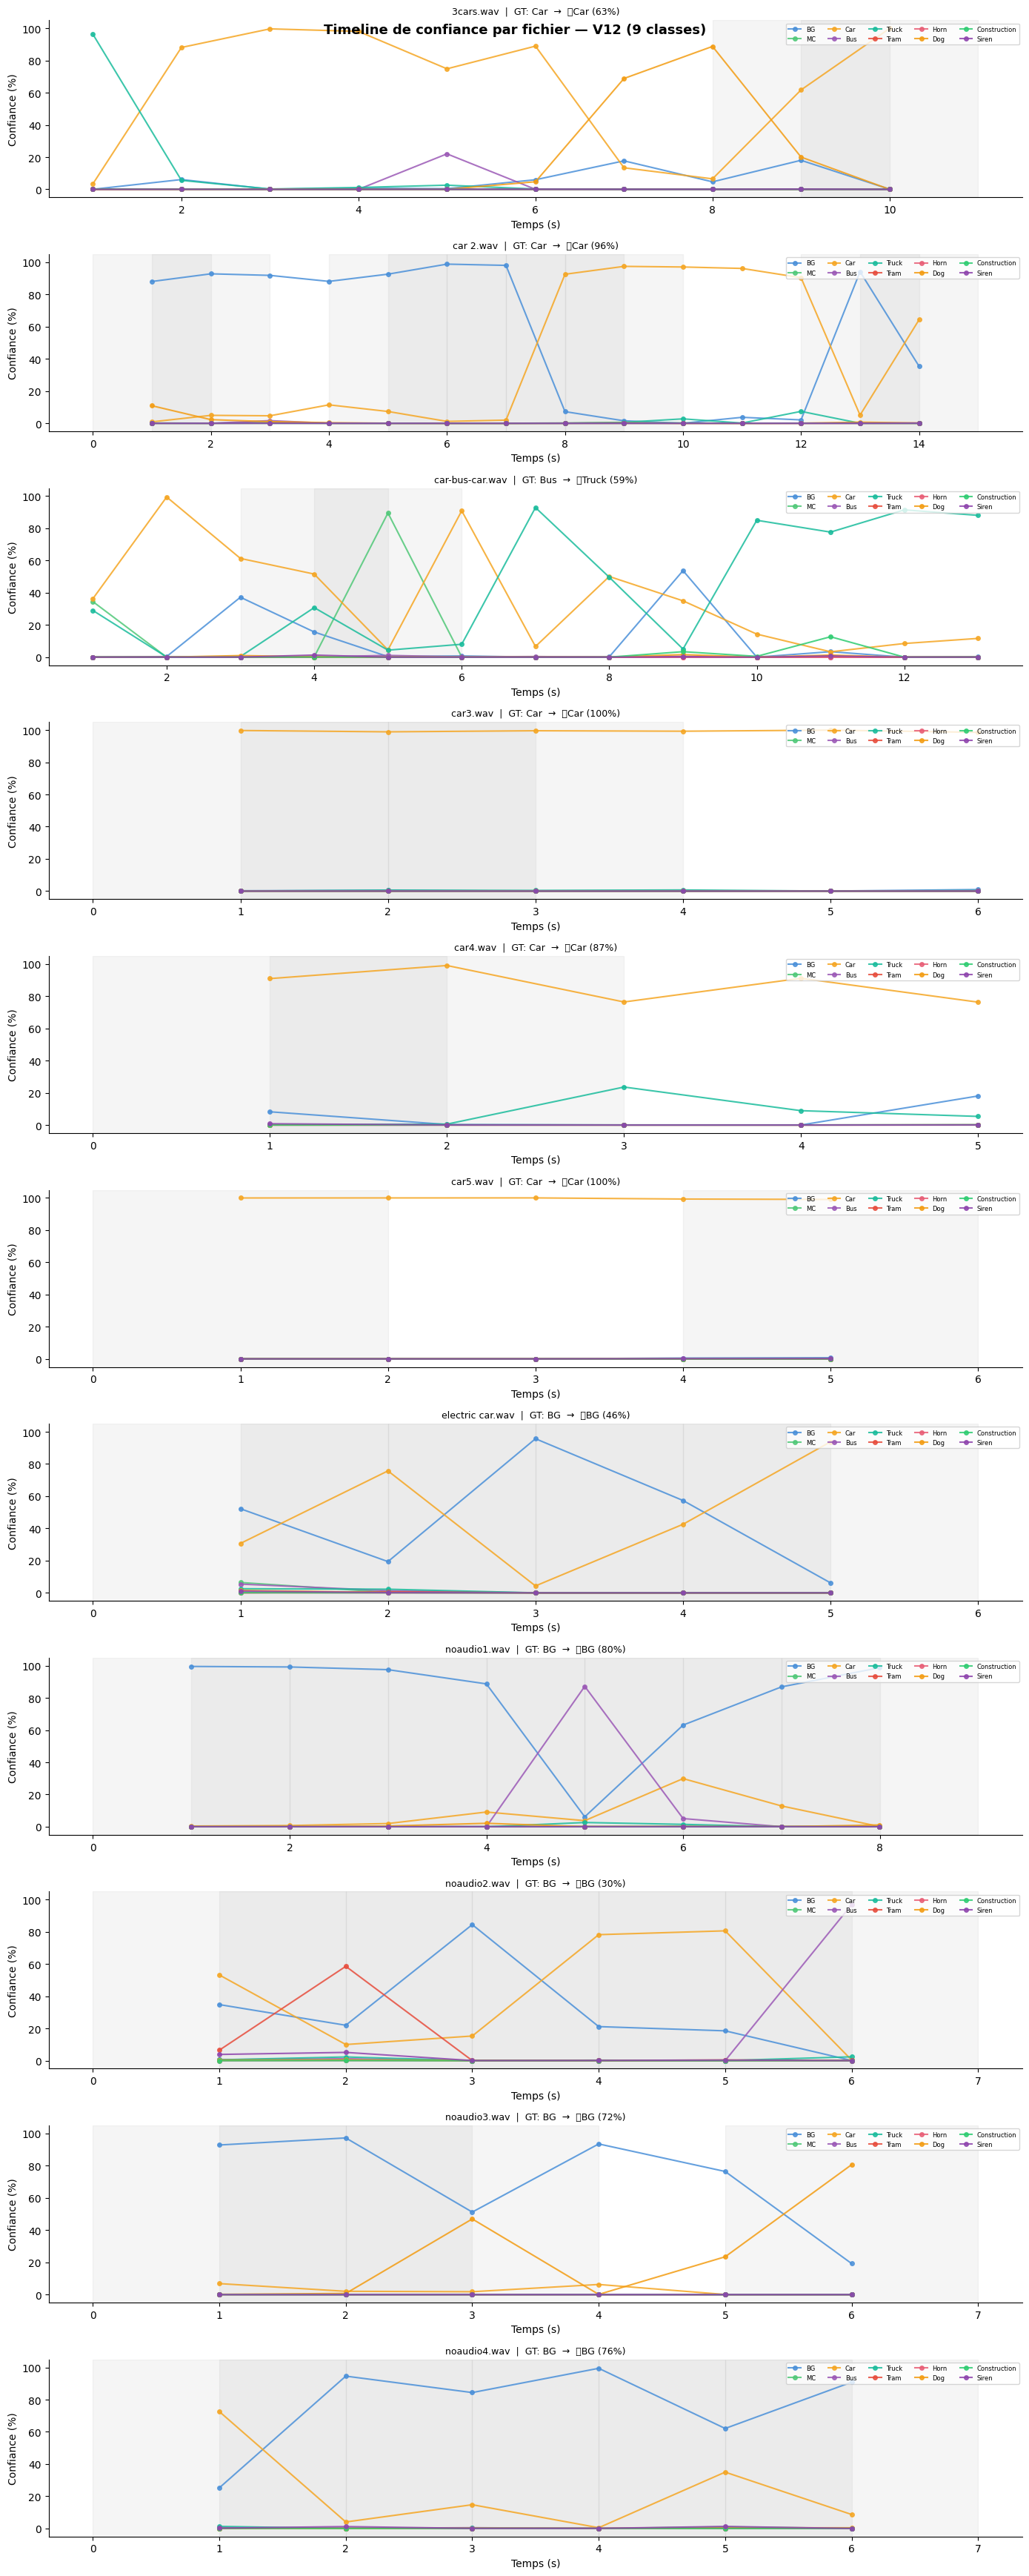

In [ ]:
def plot_inference_timeline(fname, res, true_cls, ax):
    """Window-by-window confidence timeline."""
    offsets   = res['offsets']
    all_probs = res['all_probs']
    active    = res['active_mask']
    times     = [o + WINDOW_SEC / 2 for o in offsets]

    for cls_idx, (cls_name, clr) in enumerate(zip(CLASS_LABELS_LIST, colors_pr)):
        ax.plot(times, all_probs[:, cls_idx] * 100, '-o',
                color=clr, label=cls_name, lw=1.5, ms=4, alpha=0.85)

    for i, (t, act) in enumerate(zip(times, active)):
        if not act:
            ax.axvspan(t - WINDOW_SEC/2, t + WINDOW_SEC/2,
                       alpha=0.08, color='gray', zorder=0)

    e_ok = '✅' if res['energy_pred'] == true_cls else '❌'
    ax.set_title(
        f'{fname}  |  GT: {true_cls}  →  {e_ok}{res["energy_pred"]} ({res["energy_conf"]:.0f}%)',
        fontsize=9
    )
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Confidence (%)')
    ax.set_ylim(-5, 105)
    ax.legend(fontsize=6, ncol=5, loc='upper right')
    ax.spines[['top', 'right']].set_visible(False)


if all_results:
    n_files = len(all_results)
    fig, axes = plt.subplots(n_files, 1, figsize=(14, n_files * 3.2))
    if n_files == 1:
        axes = [axes]

    for ax, (fname, res) in zip(axes, all_results.items()):
        true_cls = GROUND_TRUTH.get(fname, '?')
        plot_inference_timeline(fname, res, true_cls, ax)

    plt.suptitle('Confidence timeline per file — V12 (9 classes)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'inference_timeline_v12.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

## 25. HTML report export

In [ ]:
def generate_html_report_v12(test_acc, test_loss, ap_scores, mean_ap,
                              df_results, results_dir, num_epochs):
    """Generates a complete HTML report for V12."""
    import base64

    def img_to_b64(path):
        if not os.path.exists(path):
            return ''
        with open(path, 'rb') as f:
            return base64.b64encode(f.read()).decode()

    def img_tag(fname, title='', width='100%'):
        b64 = img_to_b64(os.path.join(results_dir, fname))
        if not b64:
            return f'<p><i>Image not available: {fname}</i></p>'
        return f'<figure><img src="data:image/png;base64,{b64}" style="width:{width}" /><figcaption>{title}</figcaption></figure>'

    inf_html = ''
    if df_results is not None and len(df_results) > 0:
        n_ok = df_results['correct_energy'].sum()
        n_total = len(df_results)
        inf_html = f'<p>Personal inference score: <b>{n_ok}/{n_total} ({n_ok/n_total*100:.1f}%)</b></p>'
        rows = ''.join(
            f"<tr><td>{r['file']}</td><td>{r['ground_truth']}</td><td>{r['pred_energy']}</td>"
            f"<td>{r['conf_energy']:.1f}%</td><td>{'✅' if r['correct_energy'] else '❌'}</td></tr>"
            for _, r in df_results.iterrows()
        )
        inf_html += f"<table border='1' cellpadding='4' style='border-collapse:collapse'>" \
                    f"<tr><th>File</th><th>Ground Truth</th><th>Predicted</th><th>Confidence</th><th>OK?</th></tr>{rows}</table>"

    ap_rows = ''.join(
        f"<tr><td>{cls}</td><td>{ap:.3f}</td><td>{'█' * int(ap*20)}</td></tr>"
        for cls, ap in ap_scores.items()
    )

    html = f"""<!DOCTYPE html>
<html lang='en'>
<head>
  <meta charset='UTF-8'>
  <title>V12 — Vehicle Audio Classifier Report</title>
  <style>
    body {{ font-family: Arial, sans-serif; max-width: 1400px; margin: auto; padding: 20px; }}
    h1   {{ color: #2c3e50; }}
    h2   {{ color: #4A90D9; border-bottom: 2px solid #4A90D9; padding-bottom: 4px; }}
    table {{ border-collapse: collapse; margin: 10px 0; }}
    td, th {{ padding: 6px 12px; border: 1px solid #ddd; }}
    th {{ background: #4A90D9; color: white; }}
    tr:nth-child(even) {{ background: #f9f9f9; }}
    figure {{ margin: 10px 0; }}
    figcaption {{ font-size: 0.85em; color: #666; text-align: center; }}
    .metric {{ display: inline-block; background: #ecf0f1; padding: 8px 16px;
               border-radius: 6px; margin: 4px; font-size: 1.1em; }}
    .good   {{ background: #d5f5e3; }}
    .new    {{ background: #fef9e7; border: 1px solid #f39c12; }}
  </style>
</head>
<body>
<h1>🚗🔔🐕🚧🚨 Vehicle Audio Classifier — V12</h1>
<p>Dataset: <b>IDMT-Traffic + Melaudis + UrbanSound8K</b> &nbsp;|&nbsp;
   Classes: <b>{NUM_CLASSES}</b> (9 classes) &nbsp;|&nbsp;
   Architecture: <b>CNN1D × 3 → BiLSTM × 2 → Self-Attention → Dense</b></p>
<p>
  <span class='metric new'>What's new in V12:</span>
  Bicycle → BG &nbsp;|&nbsp; + Horn 🔔 &nbsp;|&nbsp; + Dog 🐕 &nbsp;|&nbsp;
  + Construction 🚧 &nbsp;|&nbsp; + Siren 🚨
</p>

<h2>Global Metrics</h2>
<div class='metric good'>Test Accuracy: <b>{test_acc*100:.2f}%</b></div>
<div class='metric'>Test Loss: <b>{test_loss:.4f}</b></div>
<div class='metric'>mAP: <b>{mean_ap:.3f}</b></div>
<div class='metric'>Epochs: <b>{num_epochs}</b></div>

<h2>Average Precision by Class</h2>
<table>
  <tr><th>Class</th><th>AP</th><th>Bar</th></tr>
  {ap_rows}
  <tr><td><b>mAP</b></td><td><b>{mean_ap:.3f}</b></td><td></td></tr>
</table>

<h2>Data Distribution</h2>
{img_tag('distribution_v12.png', 'Train / validation / test distribution')}

<h2>Learning Curves</h2>
{img_tag('learning_curves_v12.png', 'Train/validation accuracy and loss')}

<h2>Confusion Matrix</h2>
{img_tag('confusion_matrix_v12.png', 'Normalized confusion matrix (global test set)')}

<h2>Precision-Recall Curves</h2>
{img_tag('pr_curves_v12.png', 'PR curves by class — mAP = ' + f'{mean_ap:.3f}')}

<h2>t-SNE Embeddings</h2>
{img_tag('tsne_v12.png', 't-SNE projection (Dense 256) — 3 sources')}

<h2>Self-Attention Heatmaps</h2>
{img_tag('attention_heatmap_v12.png', 'Attention activations by class')}

<h2>Confident Errors</h2>
{img_tag('erreurs_confiantes_v12.png', 'Top confident errors')}

<h2>Personal Inference</h2>
{inf_html}
{img_tag('inference_timeline_v12.png', 'Confidence timeline by file')}

<footer style='margin-top:40px; color:#999; font-size:0.8em'>
  Automatically generated by Vehicle Audio Classifier V12
</footer>
</body>
</html>"""

    report_path = os.path.join(results_dir, 'report_v12.html')
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(html)
    print(f'✅ HTML report exported → {report_path}')
    return report_path


generate_html_report_v12(
    test_acc     = test_acc,
    test_loss    = test_loss,
    ap_scores    = ap_scores,
    mean_ap      = mean_ap,
    df_results   = df_results if 'df_results' in dir() else None,
    results_dir  = RESULTS_DIR,
    num_epochs   = len(history.history['accuracy'])
)

✅ Rapport HTML exporté → results\rapport_v12.html


'results\\rapport_v12.html'

## 26. Final summary

In [ ]:
print('=' * 75)
print('  FINAL SUMMARY V12 — IDMT + Melaudis + UrbanSound8K')
print('=' * 75)
print(f'  Datasets         : IDMT-Traffic + Melaudis + US8K ({NUM_CLASSES} classes)')
print(f'  Classes          : {CLASS_LABELS_LIST}')
print(f'  Architecture     : Conv1D × 3 → BiLSTM × 2 → MultiHeadAttention → Dense')
print(f'  Features (V12)   : Mel({N_MELS}) + MFCC({N_MFCC}) + Chroma({N_CHROMA}) + ZCR + RMS = {FEATURE_DIM} dims')
print(f'  Augmentation     : SpecAugment (T//5, F//8) + gain [0.6, 1.4] + noise σ=0.008')
print(f'  Normalization    : target RMS {TARGET_RMS} (robust across datasets)')
print(f'  Train            : {len(X_train)} examples ({TARGET_PER_CLASS}/class)')
print(f'  Val              : {len(X_val)} examples')
print(f'  Test             : {len(X_test)} examples')
print()
print(f'  ── V12 vs V11 changes ──')
print(f'  Removed          : Bicycle (→ merged with BG, too silent)')
print(f'  Added            : Horn, Dog, Construction, Siren (US8K)')
print(f'  Electric car     : now labeled as BG (consistent with the Bicycle decision)')
print()
print(f'  ── Test metrics ──')
print(f'  Test accuracy    : {test_acc*100:.2f}%')
print(f'  Test loss        : {test_loss:.4f}')
print(f'  mAP (PR)         : {mean_ap:.3f}')
print()
print('  ── AP per class ──')
for cls, ap in ap_scores.items():
    bar = '█' * int(ap * 25)
    ok  = '✅' if ap >= 0.80 else ('⚠️ ' if ap >= 0.50 else '❌')
    print(f'  {cls:12s}: {ap:.3f}  {bar}  {ok}')
print()
if 'df_results' in dir() and len(df_results) > 0:
    for method in ['soft', 'energy']:
        n_ok = df_results[f'correct_{method}'].sum()
        print(f'  Personal inference score ({method:7s}): {n_ok}/{len(df_results)} ({n_ok/len(df_results)*100:.1f}%)')
print()
print('  Produced files (results/):')
for fname in sorted(os.listdir(RESULTS_DIR)):
    size_kb = os.path.getsize(os.path.join(RESULTS_DIR, fname)) / 1024
    print(f'    {fname:55s} {size_kb:7.1f} KB')
print('=' * 75)

  RÉCAPITULATIF FINAL V12 — IDMT + Melaudis + UrbanSound8K
  Datasets         : IDMT-Traffic + Melaudis + US8K (10 classes)
  Classes          : ['BG', 'MC', 'Car', 'Bus', 'Truck', 'Tram', 'Horn', 'Dog', 'Construction', 'Siren']
  Architecture     : Conv1D × 3 → BiLSTM × 2 → MultiHeadAttention → Dense
  Features (V12)   : Mel(128) + MFCC(40) + Chroma(12) + ZCR + RMS = 182 dims
  Augmentation     : SpecAugment (T//5, F//8) + gain [0.6, 1.4] + bruit σ=0.008
  Normalisation    : RMS cible 0.05 (robuste inter-dataset)
  Train            : 12000 exemples (1200/classe)
  Val              : 3144 exemples
  Test             : 5717 exemples

  ── Changements V12 vs V11 ──
  Supprimé         : Bicycle (→ fusionné avec BG, trop silencieux)
  Ajouté           : Horn, Dog, Construction, Siren (US8K)
  Voiture électrique: désormais étiquetée BG (cohérent avec la décision Bicycle)

  ── Métriques Test ──
  Test accuracy    : 79.27%
  Test loss        : 0.7565
  mAP (PR)         : 0.838

  ── AP par c